# Подробное исследование данных.

- Автор: Бышин М.И. (hh.ru/resume/3a27e4d7ff0ef40ab90039ed1f6f445a567078)
- 24.08.2025

**Комментарий:**
- Дал себе волю по-макисмуму изучить данные. В связи с чем, делал большое кол-во проверок. Кода получилось много. Большую часть решил оставить в тетради для понимания логики рассуждения.

#### Задание
- 1.	Провести предварительный анализ данных. Отметить, какие проблемные моменты в данных удалось найти, какие решения для устранения некорректности данных и пропусков Вы использовали. 
- 2.	Проанализировать, отличаются ли средняя сумма активов на счетах, доходность и суммы вводов/выводов у клиентов в зависимости от пола и возраста. 
- 3.	На основе имеющихся данных выделить 3-5 ключевых метрик, которые Вы предложили бы бизнесу отслеживать на регулярной основе; объяснить, почему контроль над этими метрики поможет улучшить бизнес-процессы; построить графики по этим метрикам.


#### Описание данных:

- client_id – уникальный id клиента
- gender – пол клиента (1 – муж, 2 – жен)
- birth_date – дата рождения
- region – представительство, за которым закреплен клиент
- manager – фамилия менеджера, который ведет клиента
- open_date – дата открытия счета
- close_date – дата закрытия счета
- datepost – дата наблюдения 
- assets – сумма активов на клиентском счете
- money_in – сумма введенных средств
- money_out – сумма выведенных средств
- yields – доходность клиента за все время


In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

In [2]:
# Загружаем датафрейм
df = pd.read_csv('C:/Users/Max Man/Downloads/finam_test2.csv')

### 1. Предобработка данных

#### Знакомство 

In [3]:
# Знакомимся
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1086369 entries, 0 to 1086368
Data columns (total 12 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   client_id   1086369 non-null  int64  
 1   gender      1083103 non-null  float64
 2   birth_date  1086369 non-null  object 
 3   region      1086185 non-null  object 
 4   manager     1086369 non-null  object 
 5   open_date   1086369 non-null  object 
 6   close_date  1086369 non-null  object 
 7   datepost    1086369 non-null  int64  
 8   assets      1084446 non-null  float64
 9   money_in    11981 non-null    float64
 10  money_out   6207 non-null     float64
 11  yields      1086369 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 99.5+ MB


In [4]:
# Визуальный осмотр
display(df)

,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
0,11118775,2.0,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,1727740800000,416922.3,NaN,NaN,-5.1
1,11118775,2.0,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,1727827200000,408458.9,NaN,NaN,-5.7
2,11118775,2.0,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,1727913600000,412604.0,NaN,NaN,-3.5
3,11118775,2.0,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,1728000000000,412687.7,NaN,NaN,-4.2
4,11118775,2.0,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,1728086400000,412690.2,NaN,NaN,-4.2
...,...,...,...,...,...,...,...,...,...,...,...,...
1086364,99999794,1.0,1951-08-23,Новосибирск,Валова,2023-01-24,2100-01-01,1735257600000,183358.1,NaN,NaN,-5.0
1086365,99999794,1.0,1951-08-23,Новосибирск,Валова,2023-01-24,2100-01-01,1735344000000,188751.7,NaN,NaN,-2.2
1086366,99999794,1.0,1951-08-23,Новосибирск,Валова,2023-01-24,2100-01-01,1735430400000,188751.8,NaN,NaN,-2.2
1086367,99999794,1.0,1951-08-23,Новосибирск,Валова,2023-01-24,2100-01-01,1735516800000,196525.1,NaN,NaN,-2.1


- Тип данных в столбце `gender` меняем на `int8`.
- Тип данных в столбце `birth_date` меняем на `date`.
- Тип данных в столбце `open_date` меняем на `date`.
- Тип данных в столбце `close_date` меняем на `date`.
- Тип данных в столбце `datepost` меняем на `date`
- Пропуски содержатся в столбцах: `gender`, `region`, `assets`, `money_in` и `money_out`. Критичность этого параметра определим позже.
- Проверка на уникальные значения и дубликаты позже.

#### Предобработка поля gender

In [5]:
# Выводим все строки с пропусками и считаем их кол-во
na_gender = df[df['gender'].isna()]
print(f"Всего строк с пропусками в gender: {len(na_gender)}")
display(na_gender)

Всего строк с пропусками в gender: 3266


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
109837,21656647,NaN,1991-10-21,Новосибирск,Валова,2023-03-21,2100-01-01,1727740800000,4.7,NaN,NaN,0.0
109838,21656647,NaN,1991-10-21,Новосибирск,Валова,2023-03-21,2100-01-01,1727827200000,4.7,NaN,NaN,0.0
109839,21656647,NaN,1991-10-21,Новосибирск,Валова,2023-03-21,2100-01-01,1727913600000,4.7,NaN,NaN,0.0
109840,21656647,NaN,1991-10-21,Новосибирск,Валова,2023-03-21,2100-01-01,1728000000000,4.7,NaN,NaN,0.0
109841,21656647,NaN,1991-10-21,Новосибирск,Валова,2023-03-21,2100-01-01,1728086400000,4.7,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1031356,98796148,NaN,1991-11-19,Казань,Тропинин,2023-12-04,2100-01-01,1735257600000,16831.5,NaN,NaN,0.0
1031357,98796148,NaN,1991-11-19,Казань,Тропинин,2023-12-04,2100-01-01,1735344000000,16831.8,NaN,NaN,0.0
1031358,98796148,NaN,1991-11-19,Казань,Тропинин,2023-12-04,2100-01-01,1735430400000,16832.6,NaN,NaN,0.0
1031359,98796148,NaN,1991-11-19,Казань,Тропинин,2023-12-04,2100-01-01,1735516800000,16833.6,NaN,NaN,0.0


In [7]:
# Считаем client_id с пропускам
print(f"\nУникальных client_id с пропусками: {na_gender['client_id'].nunique()}")


Уникальных client_id с пропусками: 41


In [8]:
# Группировка по client_id для визуального осмотра
group_na_gender = na_gender.groupby('client_id').size().sort_values(ascending=False)
print(f"\Кол-во пропусков по client_id:")
print(group_na_gender)

\Кол-во пропусков по client_id:
client_id
21656647    92
24449496    92
27233689    92
28616654    92
32673974    92
42447973    92
41663563    92
39917794    92
36249839    92
97245819    92
94457782    92
77698825    92
78896663    92
42653367    92
46372669    92
48949127    92
53496826    92
62955185    92
56181218    92
59762949    92
62589177    92
68456229    92
63199491    92
72182517    92
71155694    92
98536559    92
98531259    92
95959631    92
97115344    92
82572975    92
83597737    92
87698296    92
91447742    92
98796148    92
29839198    40
31988422    37
65366691    31
49625612    19
29951656     5
29194339     4
89114279     2
dtype: int64


- Попробуем заполнить пропуски значением `gender` из других строк, если оно встречается для уникального `client_id`.

In [14]:
# Пишем функцию
def gender_by_client_id(df):
    """
    Заполняет пропуски в столбце gender по client_id.
    Если у client_id есть заполненное значение gender в других строках,
    использует это значение для заполнения пропусков.
    """
    
    # Создаем копию df чтобы не изменять оригинал
    result_df = df.copy()
    
    # Находим все client_id с пропусками в gender
    missing_gender_mask = result_df['gender'].isna()
    client_ids_with_missing_gender = result_df.loc[missing_gender_mask, 'client_id'].unique()
    
    # Для каждого client_id с пропусками ищем заполненное значение gender
    for client_id in client_ids_with_missing_gender:
        # Ищем строки с этим client_id, где gender заполнен
        filled_rows = result_df[(result_df['client_id'] == client_id) & 
                               (result_df['gender'].notna())]
        
        if not filled_rows.empty:
            # Берем первое найденное значение (все значения одинаковы по условию)
            gender_value = filled_rows['gender'].iloc[0]
            
            # Заполняем пропуски для этого client_id
            result_df.loc[(result_df['client_id'] == client_id) & 
                         missing_gender_mask, 'gender'] = gender_value
    
    return result_df

# Запускаем
df = gender_by_client_id(df)

In [15]:
# Проверяем количество пропусков до и после
print(f"Пропусков до заполнения: {df['gender'].isna().sum()}")
df_filled = gender_by_client_id(df)
print(f"Пропусков после заполнения: {df_filled['gender'].isna().sum()}")

Пропусков до заполнения: 3266
Пропусков после заполнения: 3266


- Делаем вывод о том, что персечений между полем `client_id` и `gender` - нет. Сравнение с другими полями не даст стопроцентной уверенности в павильности замены пропусков.
- Заменим пропуски в столбце `gender` значение заглушку `-1`, которое будем учитывать при будущей фильтрации.

In [16]:
# Заменяем пропуски за значения заглушки
df['gender'] = df['gender'].fillna(-1)

In [17]:
# Оптимизируем тип данных в столбце с float на int8
df['gender'] = df['gender'].astype('int8')

In [18]:
# Проверяем значения в столбце
df['gender'].value_counts()

gender
 1    633812
 2    449291
-1      3266
Name: count, dtype: int64

**Поле `gender` готово для дальнейшего анализа.**

#### Предобработка поля region

In [20]:
# Выводим все строки с пропусками и считаем их кол-во
na_region = df[df['region'].isna()]
print(f"Всего строк с пропусками в region: {len(na_region)}")
display(na_region)

Всего строк с пропусками в region: 184


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
103392,19982773,2,1987-12-14,NaN,Митрохин,2023-01-17,2100-01-01,1727740800000,37322.7,NaN,NaN,-86.9
103393,19982773,2,1987-12-14,NaN,Митрохин,2023-01-17,2100-01-01,1727827200000,42461.9,NaN,NaN,-85.7
103394,19982773,2,1987-12-14,NaN,Митрохин,2023-01-17,2100-01-01,1727913600000,45834.2,NaN,NaN,-84.6
103395,19982773,2,1987-12-14,NaN,Митрохин,2023-01-17,2100-01-01,1728000000000,50250.5,NaN,NaN,-82.9
103396,19982773,2,1987-12-14,NaN,Митрохин,2023-01-17,2100-01-01,1728086400000,50248.8,NaN,NaN,-82.9
...,...,...,...,...,...,...,...,...,...,...,...,...
904885,93195176,1,1969-04-14,NaN,Митрохин,2023-01-01,2024-12-31,1735257600000,1661.7,NaN,NaN,0.0
904886,93195176,1,1969-04-14,NaN,Митрохин,2023-01-01,2024-12-31,1735344000000,1661.7,NaN,NaN,0.0
904887,93195176,1,1969-04-14,NaN,Митрохин,2023-01-01,2024-12-31,1735430400000,1661.7,NaN,NaN,0.0
904888,93195176,1,1969-04-14,NaN,Митрохин,2023-01-01,2024-12-31,1735516800000,1661.7,NaN,NaN,0.0


In [21]:
# Доп информация о пропусках
print(f"\nУникальных client_id с пропусками: {na_region['client_id'].nunique()}")
print(f"\nУникальных manager с пропусками: {na_region['manager'].nunique()}")


Уникальных client_id с пропусками: 2

Уникальных manager с пропусками: 1


- Делаем вывод о том, что имеется два клиента с одним менеджером. Ориентируясь на региональную предандлежность менеджера можно предположить на какой регион менять значения пропусков.

In [23]:
# Проверяем кол-во регионов у каждого из менеджеров
manager = df.groupby('manager')['region'].unique()
print(manager)

manager
Алексеев       [Ростов-на-Дону]
Аристов                [Москва]
Богучаева              [Москва]
Бородина          [Новосибирск]
Валова            [Новосибирск]
Величко       [Санкт-Петербург]
Георгадзе           [Краснодар]
Гуняева                [Казань]
Данилов        [Санкт-Петербур]
Денисов          [Екатеринбург]
Дуденкова                [Омск]
Еремин           [Екатеринбург]
Жуков                    [Омск]
Зимоха           [Екатеринбург]
Зинчук              [Краснодар]
Иванов                 [Москва]
Копейкин               [Москва]
Крапивин      [Санкт-Петербург]
Куренкова     [Санкт-Петербург]
Минин                  [Москва]
Митрохин          [Москва, nan]
Оганесян       [Ростов-на-Дону]
Павлова                [Москва]
Руденко           [Новосибирск]
Рябинин          [Екатеринбург]
Рябков                 [Казань]
Самойлова              [Самара]
Самохвалов        [Новосибирск]
Сидоренко           [Краснодар]
Сидоров             [Краснодар]
Тропарев               [Москва]


- За каждым менеджером закреплён один регион, это подтверждает гипотезу о замене пропусков в соответствии с регионалной принадлежностью менеджера

In [24]:
# Пишем функцию
def region_by_manager(df):
    """
    Заполняет пропуски в столбце region по полю manager.
    """
    
    # Создаем копию чтобы не изменять оригинал
    def_df = df.copy()
    
    # Находим все manager с пропусками в region
    missing_region_mask = def_df['region'].isna()
    managers_with_missing_region = def_df.loc[missing_region_mask, 'manager'].unique()
    
    # Для каждого manager с пропусками ищем заполненное значение region
    for manager in managers_with_missing_region:
        # Ищем строки с этим manager, где region заполнен
        filled_rows = def_df[(def_df['manager'] == manager) & 
                            (def_df['region'].notna())]
        
        if not filled_rows.empty:
            # Берем первое найденное значение
            region_value = filled_rows['region'].iloc[0]
            
            # Заполняем пропуски для этого manager
            def_df.loc[(def_df['manager'] == manager) & 
                      missing_region_mask, 'region'] = region_value
    
    return def_df
    
# Запускаем
df = region_by_manager(df)

In [25]:
# Проверяем результат
manager = df.groupby('manager')['region'].unique()
print(manager)

manager
Алексеев       [Ростов-на-Дону]
Аристов                [Москва]
Богучаева              [Москва]
Бородина          [Новосибирск]
Валова            [Новосибирск]
Величко       [Санкт-Петербург]
Георгадзе           [Краснодар]
Гуняева                [Казань]
Данилов        [Санкт-Петербур]
Денисов          [Екатеринбург]
Дуденкова                [Омск]
Еремин           [Екатеринбург]
Жуков                    [Омск]
Зимоха           [Екатеринбург]
Зинчук              [Краснодар]
Иванов                 [Москва]
Копейкин               [Москва]
Крапивин      [Санкт-Петербург]
Куренкова     [Санкт-Петербург]
Минин                  [Москва]
Митрохин               [Москва]
Оганесян       [Ростов-на-Дону]
Павлова                [Москва]
Руденко           [Новосибирск]
Рябинин          [Екатеринбург]
Рябков                 [Казань]
Самойлова              [Самара]
Самохвалов        [Новосибирск]
Сидоренко           [Краснодар]
Сидоров             [Краснодар]
Тропарев               [Москва]


- Уникальность значений в столбце изучим позже.

**Поле `region` готово для дальнейшего анализа.**

#### Предобработка поля assets

In [29]:
# Выводим все строки с пропусками и считаем их кол-во
na_assets = df[df['assets'].isna()]
print(f"Всего строк с пропусками в assets: {len(na_assets)}")
display(na_assets)

Всего строк с пропусками в assets: 645


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
2572,11347929,2,1984-09-10,Казань,Рябков,2024-08-23,2100-01-01,1731456000000,NaN,NaN,NaN,-7.3
4757,11523441,2,2008-04-03,Новосибирск,Руденко,2023-03-06,2100-01-01,1729814400000,NaN,NaN,NaN,-1.2
5402,11599891,1,1971-06-02,Казань,Тропинин,2024-09-08,2100-01-01,1727740800000,NaN,NaN,NaN,-19.1
7567,11792194,2,1991-09-05,Санкт-Петербург,Куренкова,2024-09-15,2100-01-01,1728345600000,NaN,2128500.0,NaN,0.0
7727,11834962,1,1952-03-29,Екатеринбург,Шапошников,2024-01-29,2100-01-01,1735603200000,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1077989,99926212,1,1962-10-25,Екатеринбург,Шапошников,2023-09-13,2100-01-01,1735603200000,NaN,NaN,NaN,-1.9
1078763,99933292,1,1977-04-03,Ростов-на-Дону,Алексеев,2023-05-10,2100-01-01,1730332800000,NaN,NaN,NaN,-83.6
1078794,99933292,1,1977-04-03,Ростов-на-Дону,Алексеев,2023-05-10,2100-01-01,1735603200000,NaN,NaN,NaN,0.0
1081916,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1728604800000,NaN,NaN,NaN,-17.0


- Выберем несколько рандомных клиентов, чтобы понять причину пропусков.

In [30]:
client_11169197 = df[df['client_id'] == 11169197]
print(f"Всего строк с клиентом 11169197: {len(client_11169197)}")
display(client_11169197)

Всего строк с клиентом 11169197: 33


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
853,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1727740800000,47.3,NaN,NaN,0.0
854,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1727827200000,47.3,NaN,NaN,0.0
855,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1727913600000,47.3,NaN,NaN,0.0
856,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1728000000000,47.3,NaN,NaN,0.0
857,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1728086400000,47.3,NaN,NaN,0.0
858,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1728172800000,47.3,NaN,NaN,0.0
859,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1728259200000,47.3,NaN,NaN,0.0
860,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1728345600000,47.3,NaN,NaN,0.0
861,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1728432000000,47.3,NaN,NaN,0.0
862,11169197,1,1994-12-19,Санкт-Петербург,Величко,2023-10-30,2100-01-01,1728518400000,47.3,NaN,NaN,0.0


In [31]:
client_11489317 = df[df['client_id'] == 11489317]
print(f"Всего строк с клиентом 11489317: {len(client_11489317)}")
display(client_11489317)

Всего строк с клиентом 11489317: 26


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
4254,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732233600000,330270.0000,331100.00,NaN,0.0
4255,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732320000000,330270.3000,NaN,NaN,0.0
4256,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732406400000,330269.4000,NaN,NaN,0.0
4257,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732492800000,330463.9000,NaN,NaN,0.1
4258,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732579200000,330634.9000,NaN,NaN,0.1
4259,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732665600000,330807.2000,NaN,NaN,0.1
4260,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732752000000,331001.9000,NaN,NaN,0.1
4261,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732838400000,331564.4000,NaN,NaN,0.2
4262,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1732924800000,331563.4000,NaN,NaN,0.0
4263,11489317,1,1976-01-16,Москва,Минин,2024-01-05,2100-01-01,1733011200000,331563.9000,NaN,NaN,0.0


In [33]:
client_21656647 = df[df['client_id'] == 99985876]
print(f"Всего строк с client_id 21656647: {len(client_21656647)}")
display(client_21656647)

Всего строк с client_id 21656647: 5


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
1083604,99985876,1,1982-06-27,Ростов-на-Дону,Оганесян,2024-09-02,2100-01-01,1727740800000,3.381731e+06,NaN,NaN,2.1
1083605,99985876,1,1982-06-27,Ростов-на-Дону,Оганесян,2024-09-02,2100-01-01,1727827200000,6.711432e+05,NaN,2.710115e+06,2.1
1083606,99985876,1,1982-06-27,Ростов-на-Дону,Оганесян,2024-09-02,2100-01-01,1727913600000,6.711432e+05,NaN,6.711432e+05,2.1
1083607,99985876,1,1982-06-27,Ростов-на-Дону,Оганесян,2024-09-02,2100-01-01,1728345600000,1.418800e+04,14190.0,NaN,2.1
1083608,99985876,1,1982-06-27,Ростов-на-Дону,Оганесян,2024-09-02,2100-01-01,1728432000000,1.419000e+04,NaN,1.419000e+04,2.1


- В большинстве, а может быть и во всех случаях, причиной пропуска является вывод денежных средств с баланса. Следовательно, можно заменить пропуски на значение строки из поля `money_out`.

In [34]:
# Пишем функцию

def assets_with_money_out(df):
    """
    Заменяет пропуски в поле assets по значению из поля money_out.
    """
    # Создаём копию
    df = df.copy()
    
    # Заполняем пропуски в assets значениями из money_out
    df['assets'] = df['assets'].fillna(df['money_out'])
    
    return df
    
# Применяем
df = assets_with_money_out(df)

In [35]:
# Проверим количество пропусков

print(f"Пропусков в assets после заполнения: {df['assets'].isna().sum()}")

Пропусков в assets после заполнения: 645


- 645 из 1923 пропсков осталось. Ещё раз выберем несколько рандомных клиентов, чтобы понять причину.

In [36]:
# Выводим все строки с пропусками
na_assets = df[df['assets'].isna()]
na_assets.head(100-300)

,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
2572,11347929,2,1984-09-10,Казань,Рябков,2024-08-23,2100-01-01,1731456000000,NaN,NaN,NaN,-7.3
4757,11523441,2,2008-04-03,Новосибирск,Руденко,2023-03-06,2100-01-01,1729814400000,NaN,NaN,NaN,-1.2
5402,11599891,1,1971-06-02,Казань,Тропинин,2024-09-08,2100-01-01,1727740800000,NaN,NaN,NaN,-19.1
7567,11792194,2,1991-09-05,Санкт-Петербург,Куренкова,2024-09-15,2100-01-01,1728345600000,NaN,2128500.0,NaN,0.0
7727,11834962,1,1952-03-29,Екатеринбург,Шапошников,2024-01-29,2100-01-01,1735603200000,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
757516,79972761,1,1971-09-10,Москва,Иванов,2024-02-01,2100-01-01,1735603200000,NaN,NaN,NaN,0.0
759487,81265399,2,1991-01-21,Ростов-на-Дону,Оганесян,2023-06-01,2100-01-01,1735603200000,NaN,NaN,NaN,0.0
762822,81529884,1,1985-11-11,Ростов-на-Дону,Алексеев,2023-12-28,2100-01-01,1734652800000,NaN,NaN,NaN,-14.4
764647,81752432,2,1955-11-10,Новосибирск,Бородина,2023-11-24,2100-01-01,1731628800000,NaN,47300.0,NaN,0.0


In [37]:
client_11792194 = df[df['client_id'] == 11792194]
print(f"Всего строк с клиентом 11792194: {len(client_11792194)}")
display(client_11792194)

Всего строк с клиентом 11792194: 1


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
7567,11792194,2,1991-09-05,Санкт-Петербург,Куренкова,2024-09-15,2100-01-01,1728345600000,NaN,2128500.0,NaN,0.0


In [38]:
client_99968974 = df[df['client_id'] == 99968974]
print(f"Всего строк с клиентом 99968974: {len(client_99968974)}")
display(client_99968974)

Всего строк с клиентом 99968974: 1


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
1082315,99968974,1,1972-11-28,Самара,Самойлова,2024-12-26,2100-01-01,1735257600000,NaN,1040600.0,NaN,0.0


In [39]:
client_81752432 = df[df['client_id'] == 81752432]
print(f"Всего строк с клиентом 81752432: {len(client_81752432)}")
display(client_81752432)

Всего строк с клиентом 81752432: 2


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
764647,81752432,2,1955-11-10,Новосибирск,Бородина,2023-11-24,2100-01-01,1731628800000,NaN,47300.0,NaN,0.0
764648,81752432,2,1955-11-10,Новосибирск,Бородина,2023-11-24,2100-01-01,1734307200000,NaN,24123.0,NaN,0.0


- Нарисовалась ещё одна причина пропусков в столбце `assets`, а имеено, это время пополнения баланса клиентом. Следовательно, можно заменить пропуск на значение столбца `money_in`.

In [41]:
# Используем уже знакомую функцию c небольшими изменениями

def assets_with_money_in(df):
    """
      Заменяет пропуски в поле assets по значению из поля money_in.
    """
    # Создаём копию
    df = df.copy()
    
    # Заполняем пропуски в assets значениями из money_in
    df['assets'] = df['assets'].fillna(df['money_in'])
    
    return df

# Применякем
df = assets_with_money_in(df)

In [42]:
# Проверим количество пропусков

print(f"Пропусков в assets после заполнения: {df['assets'].isna().sum()}")

Пропусков в assets после заполнения: 596


- Количество пропусков сократилось, но не сильно. Ещё раз выберем несколько рандомных клиентов, чтобы понять причину.

In [43]:
# Выводим все строки с пропусками
na_assets = df[df['assets'].isna()]
display(na_assets)

,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
2572,11347929,2,1984-09-10,Казань,Рябков,2024-08-23,2100-01-01,1731456000000,NaN,NaN,NaN,-7.3
4757,11523441,2,2008-04-03,Новосибирск,Руденко,2023-03-06,2100-01-01,1729814400000,NaN,NaN,NaN,-1.2
5402,11599891,1,1971-06-02,Казань,Тропинин,2024-09-08,2100-01-01,1727740800000,NaN,NaN,NaN,-19.1
7727,11834962,1,1952-03-29,Екатеринбург,Шапошников,2024-01-29,2100-01-01,1735603200000,NaN,NaN,NaN,0.0
10395,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1731542400000,NaN,NaN,NaN,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1076910,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1733702400000,NaN,NaN,NaN,-11.7
1077989,99926212,1,1962-10-25,Екатеринбург,Шапошников,2023-09-13,2100-01-01,1735603200000,NaN,NaN,NaN,-1.9
1078763,99933292,1,1977-04-03,Ростов-на-Дону,Алексеев,2023-05-10,2100-01-01,1730332800000,NaN,NaN,NaN,-83.6
1078794,99933292,1,1977-04-03,Ростов-на-Дону,Алексеев,2023-05-10,2100-01-01,1735603200000,NaN,NaN,NaN,0.0


- Смотрим клиентов.

In [44]:
client_81752432 = df[df['client_id'] == 99966925]
print(f"Всего строк с клиентом 81752432: {len(client_81752432)}")
display(client_81752432)

Всего строк с клиентом 81752432: 11


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
1081906,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1727740800000,2974.2,NaN,NaN,-17.0
1081907,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1727827200000,2972.5,NaN,NaN,-17.0
1081908,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1727913600000,2974.1,NaN,NaN,-17.0
1081909,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1728000000000,2971.3,NaN,NaN,-17.0
1081910,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1728086400000,2972.8,NaN,NaN,-17.0
1081911,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1728172800000,2971.5,NaN,NaN,-17.0
1081912,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1728259200000,233754.9,NaN,NaN,-17.0
1081913,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1728345600000,233719.1,NaN,NaN,-17.0
1081914,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1728432000000,233678.6,NaN,NaN,-17.0
1081915,99966925,1,1981-01-30,Москва,Павлова,2024-01-07,2100-01-01,1728518400000,233643.3,NaN,NaN,-17.0


In [45]:
client_81752432 = df[df['client_id'] == 99913239]
print(f"Всего строк с клиентом 81752432: {len(client_81752432)}")
display(client_81752432)

Всего строк с клиентом 81752432: 18


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
1076893,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732233600000,16081.9,NaN,NaN,0.0
1076894,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732320000000,16080.2,NaN,NaN,0.0
1076895,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732406400000,16079.1,NaN,NaN,0.0
1076896,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732492800000,23545.6,NaN,NaN,46.4
1076897,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732579200000,162462.9,118250.0,NaN,46.4
1076898,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732665600000,175678.2,NaN,NaN,58.3
1076899,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732752000000,189132.4,NaN,NaN,70.5
1076900,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732838400000,133841.5,NaN,NaN,20.6
1076901,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1732924800000,133840.5,NaN,NaN,20.6
1076902,99913239,1,1988-10-29,Екатеринбург,Денисов,2024-11-22,2100-01-01,1733011200000,133837.5,NaN,NaN,20.6


In [46]:
client_81752432 = df[df['client_id'] == 12116144]
print(f"Всего строк с клиентом 81752432: {len(client_81752432)}")
display(client_81752432) 

Всего строк с клиентом 81752432: 46


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
10351,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1727740800000,71526240.7,NaN,NaN,1.6
10352,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1727827200000,73214024.5,NaN,NaN,4.0
10353,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1727913600000,73913312.9,NaN,NaN,5.0
10354,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1728000000000,72320472.8,NaN,NaN,2.7
10355,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1728086400000,73182043.3,NaN,NaN,2.7
10356,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1728172800000,73182043.1,NaN,NaN,2.7
10357,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1728259200000,71755532.5,NaN,NaN,1.9
10358,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1728345600000,66069045.2,NaN,NaN,-6.1
10359,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1728432000000,74705514.1,NaN,NaN,6.1
10360,12116144,1,1975-05-09,Краснодар,Зинчук,2023-06-22,2100-01-01,1728518400000,73733817.1,NaN,NaN,4.8


- Не зная специфики отрасли и особеностей данных, сложно найти причину оставшихся пропусков. Возможно, какая-то часть отфильтруется при работе с поиском дубликатов. Жду пояснений.
- А пока, отметим эти строки занчениями заглушками `-1`, котороые будем фильтровать.

In [47]:
# Заменяем пропуски за значения заглушки
df['assets'] = df['assets'].fillna(-1)

**Поле `assets` готово для дальнейшего анализа.**

#### Предобработка полей birth_date, open_date, close_date и datepost

Данные в поле `datepost` содержат временные метки в формате Unix. Необходимо привести их формату `datetime`.

In [48]:
# Преобразование в datetime
df['datepost'] = pd.to_datetime(df['datepost'], unit='ms')

В остальных полях меняем тип на `datetime`.
- Поле `birth_date` оказалось проблемным, не все данные корректно форматировались в нужный формат. Было запущено большое кол-во итераций для решения этой проблемы, много чернового кода и расчётов. Всё лишнее удалил, чтобы не мусорить в тетради, оставил только последние версии функций с подробным описанием каждого шага и логики.

In [50]:
# Пишем функцию
def convert_date_columns(df, date_columns=['birth_date', 'open_date', 'close_date']):
    """
    Преобразует указанные столбцы в формат datetime.
    """
    # Создаем копию
    df_result = df.copy()
    
    # Перебираем все указанные столбцы для преобразования
    for column in date_columns:
        # Проверяем, существует ли столбец в df
        if column in df_result.columns:
            # Для столбца birth_date сохраняем оригинальные значения перед преобразованием
            if column == 'birth_date':
                # Копируем оригинальные значения для последующей обработки проблемных случаев
                original_birth_dates = df_result[column].copy()
            
            # Столбец datetime
            df_result[column] = pd.to_datetime(df_result[column], errors='coerce') # coerce означает, что проблемные значения будут преобразованы в nat
            
            # Дополнительная обработка для столбца birth_date
            if column == 'birth_date':
                # Создаем маску для значений, которые содержат время (не равны 00:00:00)
                time_mask = df_result[column].notna() & (df_result[column].dt.time != pd.Timestamp('00:00:00').time())
                
                # Если есть значения с временем
                if time_mask.any():
                    # Преобразуем значения с временем в чистые даты (убираем время)
                    df_result.loc[time_mask, column] = df_result.loc[time_mask, column].dt.date
                    # Конвертируем обратно в datetime
                    df_result[column] = pd.to_datetime(df_result[column], errors='coerce')
                
                # Ищем значения nat после преобразования
                problematic_mask = df_result[column].isna()
                
                # Если есть проблемные значения
                if problematic_mask.any():
                    # Получаем индексы проблемных записей
                    problematic_indices = df_result[problematic_mask].index
                    
                    # Перебираем все проблемные записи
                    for idx in problematic_indices:
                        # Берем оригинальное значение из сохраненной копии
                        original_val = original_birth_dates[idx]
                        # Пытаемся исправить с помощью дополнительной функции
                        fixed_date = try_fix_dates(original_val)
                        
                        # Если исправление удалось
                        if not pd.isna(fixed_date):
                            # Заменяем проблемное значение на исправленное
                            df_result.loc[idx, column] = fixed_date
    
    # Возвращаем преобразованный датасет
    return df_result

# Ещё одна функция для обработки дат
def try_fix_dates(date_str):
    """
    Пытается исправить распространенные проблемы с датами.
    """
    # Проверяем является ли значение nan или не строкой
    if pd.isna(date_str) or not isinstance(date_str, str):
        # Возвращаем nan если значение невозможно обработать
        return np.nan
    
    # Преобразуем в строку и удаляем лишние пробелы
    date_str = str(date_str).strip()
    
    # Список форматов дат для попытки преобразования
    formats_to_try = [
        '%Y-%m-%d', '%Y/%m/%d', '%Y.%m.%d',  # Форматы с разделителями -/.
        '%d-%m-%Y', '%d/%m/%Y', '%d.%m.%Y',  # Форматы с днем first
        '%m-%d-%Y', '%m/%d/%Y', '%m.%d.%Y',  # Форматы с месяцем first
        '%Y%m%d', '%d%m%Y', '%m%d%Y'         # Форматы без разделителей
    ]
    
    # Пробуем каждый формат по очереди
    for fmt in formats_to_try:
        try:
            # Пытаемся преобразовать с конкретным форматом
            return pd.to_datetime(date_str, format=fmt, errors='raise') # raise выбрасывает исключение при ошибке
        except:
            # Если преобразование не удалось, пробуем следующий формат
            continue
    
    # Если есть пробел в строке, возможно это дата с временем
    if ' ' in date_str:
        # Берем только часть до пробела (дату)
        date_part = date_str.split(' ')[0]
        try:
            # Пробуем преобразовать только дату
            return pd.to_datetime(date_part, errors='raise')
        except:
            # Если не удалось, продолжаем
            pass
    
    # Если ни один формат не подошел, возвращаем nan
    return np.nan

# Запускаем
df = convert_date_columns(df)

In [51]:
# Проверяем формат
print(df[['datepost', 'birth_date', 'open_date', 'close_date']].dtypes)

datepost      datetime64[ns]
birth_date    datetime64[ns]
open_date     datetime64[ns]
close_date    datetime64[ns]
dtype: object


In [52]:
# Проверяем строки
for col in ['birth_date', 'open_date', 'close_date']:
    null_count = df[col].isnull().sum()
    print(f"Пропущенных значений в {col}: {null_count}")

Пропущенных значений в birth_date: 0
Пропущенных значений в open_date: 0
Пропущенных значений в close_date: 0


**Поля `birth_date, open_date, close_date` готовы для дальнейшего анализа.**

#### Проверяем наличие дубликатов.

In [53]:
# Проверяем наличие явных дубликатов
df.duplicated().sum()

np.int64(1)

In [54]:
# Визуально осмотрим
duplicates = df[df.duplicated(keep=False)]  #показываем все дубликаты
display(duplicates)

,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
766023,81895295,2,1989-03-05,Казань,Гуняева,2024-12-31,2100-01-01,2024-12-31,2365.2,2365.0,NaN,0.0
766024,81895295,2,1989-03-05,Казань,Гуняева,2024-12-31,2100-01-01,2024-12-31,2365.2,2365.0,NaN,0.0


In [56]:
# Удаляем
df = df.drop_duplicates()

# Проверяем
df.duplicated().sum()

np.int64(0)

#### Проверяем наличие уникальных и аномальных значений в данных.

In [57]:
# Визуальный осмотр поля region
df['region'].value_counts().sort_index # Сортируем по алфавиту

<bound method Series.sort_index of region
Москва             218584
Санкт-Петербург    157323
Казань             139961
Екатеринбург       122601
Ростов-на-Дону     107812
Краснодар          106189
Новосибирск        100331
Омск                80295
Самара              35755
Санкт-Петербур      17517
Name: count, dtype: int64>

- Необходимо исправить значения с `Санкт-Петербур` на `Санкт-Петербург`

In [58]:
# Исправляем
df['region'] = df['region'].replace('Санкт-Петербур', 'Санкт-Петербург')

In [59]:
# Проверяем
df['region'].value_counts().sort_index() # Сортируем по алфавиту

region
Екатеринбург       122601
Казань             139961
Краснодар          106189
Москва             218584
Новосибирск        100331
Омск                80295
Ростов-на-Дону     107812
Самара              35755
Санкт-Петербург    174840
Name: count, dtype: int64

In [60]:
# Визуальный осмотр поля manager
df['manager'].value_counts().sort_index() # Сортируем по алфавиту

manager
Алексеев      59719
Аристов       12858
Богучаева     30798
Бородина      14294
Валова        24896
Величко       54596
Георгадзе     12381
Гуняева       49645
Данилов       17517
Денисов       46265
Дуденкова     42291
Еремин        26210
Жуков         38004
Зимоха        10327
Зинчук        46436
Иванов        38525
Копейкин      24414
Крапивин      44181
Куренкова     40345
Минин         22665
Митрохин      17633
Оганесян      48093
Павлова       45480
Руденко       41190
Рябинин        6292
Рябков        52037
Самойлова     35755
Самохвалов    19951
Сидоренко     17619
Сидоров       29753
Тропарев      26211
Тропинин      38279
Шапошников    33507
Шувалов       18201
Name: count, dtype: int64

- Ошибочных знаяений не выявлено.

**Поля формата `object` готовы для дальнейшего анализа.**

In [61]:
# Проверим наличие аномальных значений для столбцов с числами и датами
columns_check = ['birth_date', 'open_date', 'close_date', 'datepost', 'assets', 'money_in', 'money_out', 'yields']

for col in columns_check:
    if col in df.columns:
        print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")
    else:
        print(f"Столбец {col} не найден")

birth_date: min = 1932-11-24 00:00:00, max = 2022-12-01 00:00:00
open_date: min = 2023-01-01 00:00:00, max = 2024-12-31 00:00:00
close_date: min = 2024-10-03 00:00:00, max = 2100-01-01 00:00:00
datepost: min = 2024-10-01 00:00:00, max = 2024-12-31 00:00:00
assets: min = -5664659.9, max = 3080652040.7
money_in: min = 0.0946, max = 614900000.0
money_out: min = 0.0946, max = 273799220.23520005
yields: min = -169.3, max = 11817136.6


- В поле `birth_date`: max = `2022-12-01` - вызывает подозрение. При дальнейшем анализе стоит обратить внимание на то, что брокерский счёт можно открывать при достижении совершенолетия. То есть, макисмальный показатель в этом поле должен быть датирован 2004 годом.
- В поле `close_date`: max = `2100-01-01`- не вызывает подозрения, так как, это заглушка указывающая на то, что клиент ещё не закрыл свой счёт.
- В поле `assets`: присутсвуют значения с отрицательной суммой. В описании данных нет уточнения на этот счёт(возможно так отмечается торговля с плечём или кредит или что-то ещё). Необходимо более подробно изучть данные и контекст.
- В поле `yields`: `min = -169.3`, `max = 11817136.6` оба значения выглядят аномально. Стоит учитывать это при дальнейшем анализе.
- Остальные поля выглядят корректно.

#### Доп обработка поля assets

In [62]:
# Количество всех записей в столбце
count = df['assets'].count()
print(f"Всего записей: {count}")

# Количество записей где assets > 0
normal = (df['assets'] > 0).sum()
print(f"Записей с положительным балансом: {normal}")

# Разница
diff = count - normal
percent = round(diff / count * 100,2)
print(f"Записей с отрицательным балансом: {diff} или {percent}% от общего кол-ва записей.")

Всего записей: 1086368
Записей с положительным балансом: 1084897
Записей с отрицательным балансом: 1471 или 0.14% от общего кол-ва записей.


In [63]:
# Визуально осмотрим
diff_df = df[df['assets'] < -1] # Так как значение -1 это заглушка
per = round(len(diff_df) / count * 100,2)
print(f'Запсией с отрицательным балансом с учётом заглушки: {len(diff_df)} или {per}% от общего кол-ва записей.')
display(diff_df)

Запсией с отрицательным балансом с учётом заглушки: 872 или 0.08% от общего кол-ва записей.


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
97749,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-12-24,-24160.8,25376450.0,NaN,0.0
194735,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-01,-878.9,NaN,NaN,-100.0
194787,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-11-22,-85.8,NaN,NaN,-100.0
194788,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-11-23,-85.8,NaN,NaN,-100.0
194789,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-11-24,-85.8,NaN,NaN,-100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
912791,93547794,2,1987-08-13,Екатеринбург,Денисов,2024-05-02,2100-01-01,2024-11-05,-74.6,NaN,NaN,-98.3
948078,95211288,1,1974-02-27,Омск,Дуденкова,2024-10-10,2100-01-01,2024-10-31,-10.2,NaN,NaN,-72.8
948079,95211288,1,1974-02-27,Омск,Дуденкова,2024-10-10,2100-01-01,2024-11-01,-10.2,NaN,NaN,-72.8
948080,95211288,1,1974-02-27,Омск,Дуденкова,2024-10-10,2100-01-01,2024-11-02,-10.3,NaN,NaN,-72.8


- Визуальный осмотр не помог определить причину отрицательного баланса, необходмио изучить эти показатели в разрезе клиента.

In [64]:
# Изучим несколько рандомных клиентов
client_19763553 = df[df['client_id'] == 19763553]
print(f"Всего строк с клиентом 19763553: {len(client_19763553)}")
display(client_19763553)

Всего строк с клиентом 19763553: 51


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
97706,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-11,28879.0,7095000.0,NaN,0.0
97707,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-12,28878.5,NaN,NaN,0.0
97708,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-13,28876.2,NaN,NaN,0.0
97709,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-14,28877.8,NaN,NaN,0.0
97710,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-15,28876.1,NaN,NaN,0.0
97711,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-16,28878.4,NaN,NaN,0.0
97712,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-17,28878.0,NaN,NaN,0.0
97713,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-18,28878.4,NaN,NaN,0.0
97714,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-19,28877.2,NaN,NaN,0.0
97715,19763553,2,1974-09-16,Ростов-на-Дону,Оганесян,2024-11-08,2100-01-01,2024-11-20,28877.1,NaN,NaN,0.0


In [65]:
client_98372995 = df[df['client_id'] == 98372995]
print(f"Всего строк с клиентом 98372995: {len(client_98372995)}")
client_98372995.head(50)

Всего строк с клиентом 98372995: 92


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
1020198,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-01,174245172.5,NaN,NaN,3.8
1020199,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-02,174245173.7,NaN,NaN,3.6
1020200,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-03,174245173.6,NaN,NaN,3.3
1020201,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-04,85.3,NaN,1.269452e+08,3.4
1020202,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-05,85.3,NaN,NaN,3.4
1020203,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-06,85.3,NaN,NaN,3.4
1020204,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-07,86.3,NaN,NaN,3.3
1020205,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-08,86.4,NaN,NaN,3.6
1020206,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-09,87.1,NaN,NaN,3.6
1020207,98372995,1,1980-03-04,Екатеринбург,Еремин,2023-06-16,2100-01-01,2024-10-10,87.4,NaN,NaN,3.5


In [66]:
client_28998898 = df[df['client_id'] == 28998898]
print(f"Всего строк с клиентом 28998898: {len(client_28998898)}")
client_28998898.head(50)

Всего строк с клиентом 28998898: 92


,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields
194735,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-01,-878.9,NaN,NaN,-100.0
194736,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-02,6008.5,4730.0,NaN,-100.0
194737,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-03,148.9,NaN,NaN,-100.0
194738,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-04,7245.1,7095.0,NaN,-100.0
194739,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-05,7245.5,NaN,NaN,-100.0
194740,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-06,7244.5,NaN,NaN,-100.0
194741,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-07,12862.6,7095.0,NaN,-100.0
194742,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-08,7594.3,NaN,NaN,-100.0
194743,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-09,16000.6,7095.0,NaN,-100.0
194744,28998898,2,1987-05-05,Санкт-Петербург,Куренкова,2024-08-13,2100-01-01,2024-10-10,66679.5,7095.0,NaN,-100.0


- Сложно сделать однозначные выводы. Но, учитывая, что процент значений с отрицательным балансом менее 0.14%, следовательно, фильтрация по значению >0 не сильно повлияет на итоговый результат исследования.
- Жду пояснений.
- Далее, изучим анамальные значения и выбросы.

In [68]:
# Детальная статистика
assets_stats = df['assets'].describe(percentiles=[.01, .05, .1, .25, .5, .75, .875, .9, .95, .99, .999])
print("Статистика по балансам:")
print(assets_stats.apply(lambda x: f"{x:,.2f}"))

# Анализ по методу IQR
Q1 = df['assets'].quantile(0.25)
Q3 = df['assets'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)  # Не может быть меньше 0
upper_bound = Q3 + 1.5 * IQR

outliers_assets = df[(df['assets'] < lower_bound) | (df['assets'] > upper_bound)]

# Смотрим
print(f"\nАнализ выбросов по правилу 1.5*IQR:")
print(f"Количество выбросов: {len(outliers_assets):,}")
print(f"Процент выбросов: {len(outliers_assets)/len(df)*100:.2f}%")

Статистика по балансам:
count        1,086,368.00
mean         3,914,126.67
std         42,914,476.68
min         -5,664,659.90
1%                   1.47
5%                 123.60
10%                849.21
25%             11,952.77
50%            209,938.70
75%          1,344,706.18
87.5%        3,460,093.65
90%          4,489,645.86
95%          9,805,574.86
99%         51,648,032.81
99.9%      384,241,413.02
max      3,080,652,040.70
Name: assets, dtype: object

Анализ выбросов по правилу 1.5*IQR:
Количество выбросов: 140,885
Процент выбросов: 12.97%


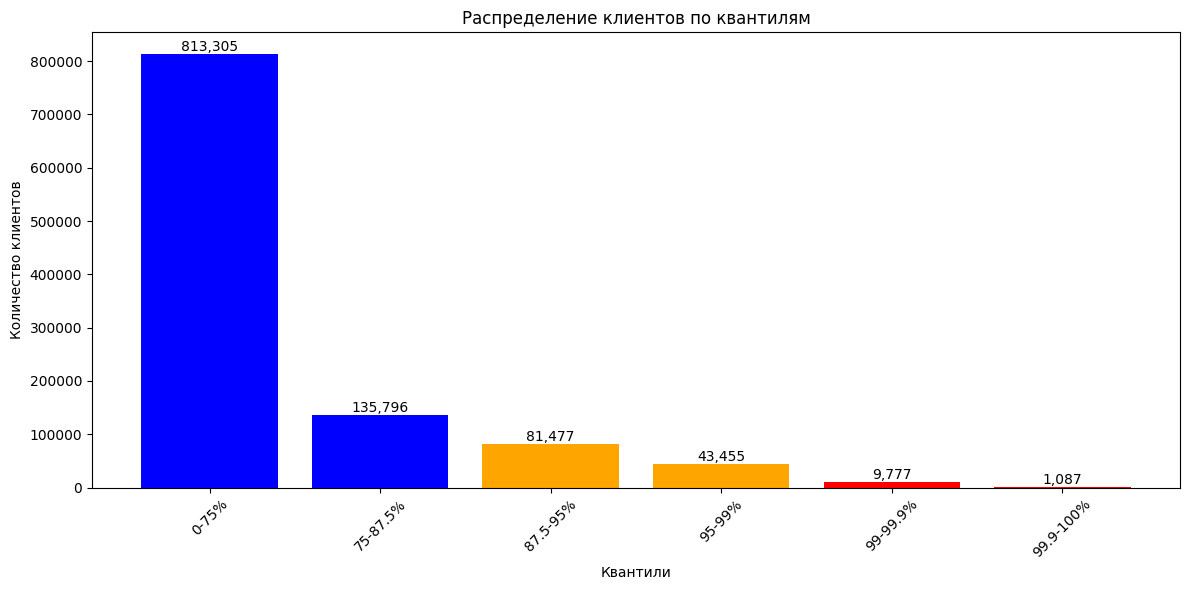

Количество клиентов в каждой категории:
assets_category
0-75%        813305
75-87.5%     135796
87.5-95%      81477
95-99%        43455
99-99.9%       9777
99.9-100%      1087
Name: count, dtype: int64


In [69]:
# Визуализируем количество по квантилям
bins = [0, 
        df['assets'].quantile(0.75),
        df['assets'].quantile(0.875),
        df['assets'].quantile(0.95),
        df['assets'].quantile(0.99),
        df['assets'].quantile(0.999),
        df['assets'].max()]

labels = ['0-75%', '75-87.5%', '87.5-95%', '95-99%', '99-99.9%', '99.9-100%']

df['assets_category'] = pd.cut(df['assets'], bins=bins, labels=labels, include_lowest=True)

# Визуализация количества наблюдений в каждой категории
plt.figure(figsize=(12, 6))
category_counts = df['assets_category'].value_counts().sort_index()
bars = plt.bar(category_counts.index, category_counts.values, color=['blue', 'blue', 'orange', 'orange', 'red', 'red'])

# Добавляем подписи значений
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,}', ha='center', va='bottom')

plt.title('Распределение клиентов по квантилям')
plt.xlabel('Квантили')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Смотрим
print("Количество клиентов в каждой категории:")
print(category_counts)

**Отсутсвует детальное описание данных(когорты и тд). Значительный размах в значениях сильно исказит средние показатели и итоговый результат. Более правильным подходом будет разделение клиентов на обычных и крупных. Например, до `0-75%` - `обычные` и `75-100%` - `VIP`. И по отдельности анализировать две группы. Создадим новый столбец `status`, со значениями `normal` и `vip`.
Жду пояснений.**


In [70]:
# Удалим лишний столбец с категорями
df = df.drop('assets_category', axis=1)

# Определяем границу 75-квантиля
q75 = df['assets'].quantile(0.75)

# Создаем новый столбец
df['status'] = np.where(df['assets'] <= q75, 'normal', 'vip')

# Проверяем
print(f"\nРаспределение по статусам:")
status_counts = df['status'].value_counts()
print(status_counts)
print(f"\nПроцентное соотношение:")
status_percentages = df['status'].value_counts(normalize=True) * 100
print(status_percentages.round(2))


Распределение по статусам:
status
normal    814776
vip       271592
Name: count, dtype: int64

Процентное соотношение:
status
normal    75.0
vip       25.0
Name: proportion, dtype: float64


**Поле `assets` готово для дальнейшего анализа.**

#### Доп обработка столбца yields

In [72]:
# Детальная статистика
yields_stats = df['yields'].describe(percentiles=[.001, .01, .05, .1, .25, .5, .75, .9, .95, .99, .999])
print("Детальная статистика:")
print(yields_stats.apply(lambda x: f"{x:.6f}"))

Детальная статистика:
count     1086368.000000
mean           63.019389
std         27590.507263
min          -169.300000
0.1%         -100.000000
1%            -82.000000
5%            -38.600000
10%           -21.000000
25%            -8.500000
50%            -0.300000
75%             0.400000
90%             8.000000
95%            17.100000
99%            52.700000
99.9%         185.463300
max      11817136.600000
Name: yields, dtype: object


In [73]:
# Анализ по методу IQR
Q1 = df['yields'].quantile(0.25)
Q3 = df['yields'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_yields = df[(df['yields'] < lower_bound) | (df['yields'] > upper_bound)]
print(f"\nАнализ выбросов по правилу 1.5*IQR:")
print(f"Границы: [{lower_bound:.2f}%, {upper_bound:.2f}%]")
print(f"Количество выбросов: {len(outliers_yields):,}")
print(f"Процент выбросов: {len(outliers_yields)/len(df)*100:.2f}%")

# Анализ экстремальных значений
print(f"\nЭкстремально низкие значения (< 0.1%):")
extreme_low = df[df['yields'] < df['yields'].quantile(0.001)]
print(f"Количество: {len(extreme_low)}")
print(f"Диапазон: {extreme_low['yields'].min():.2f}% - {extreme_low['yields'].max():.2f}%")

print(f"\nЭкстремально высокие значения (> 99.9%):")
extreme_high = df[df['yields'] > df['yields'].quantile(0.999)]
print(f"Количество: {len(extreme_high)}")
print(f"Диапазон: {extreme_high['yields'].min():.2f}% - {extreme_high['yields'].max():.2f}%")


Анализ выбросов по правилу 1.5*IQR:
Границы: [-21.85%, 13.75%]
Количество выбросов: 171,519
Процент выбросов: 15.79%

Экстремально низкие значения (< 0.1%):
Количество: 71
Диапазон: -169.30% - -100.10%

Экстремально высокие значения (> 99.9%):
Количество: 1087
Диапазон: 185.50% - 11817136.60%


- Вызывает подозрение отрицательная доходность ниже уровня `-100%`. Так как, `-100%`, это полная потеря средств. Так-же, как и значение `+11817136.60%`. Изучим более подробно экстримально-высокие значения.

In [74]:
# Группируем и считаем среднюю доходность для каждого клиента
client_avg_yields = df.groupby('client_id')['yields'].agg(['mean', 'count', 'std', 'min', 'max'])

# Сортируем по средней доходности и берем топ-20
top_10_clients = client_avg_yields.nlargest(20, 'mean')

# Форматируем значения
formatted_df = top_10_clients.copy()
formatted_df['mean'] = formatted_df['mean'].apply(lambda x: f"{x:10.2f}%")
formatted_df['count'] = formatted_df['count'].apply(lambda x: f"{x:8.0f}")
formatted_df['std'] = formatted_df['std'].apply(lambda x: f"{x:8.2f}")
formatted_df['min'] = formatted_df['min'].apply(lambda x: f"{x:8.2f}%")
formatted_df['max'] = formatted_df['max'].apply(lambda x: f"{x:8.2f}%")

# Смотрим
print(formatted_df.to_string(index=True))

                  mean     count         std        min           max
client_id                                                            
84411628    783338.29%        90  2944489.15    398.50%  11817136.60%
82557857     27750.10%        92    25018.47   2962.20%     83349.90%
32388639      9634.60%         3        0.00   9634.60%      9634.60%
82783795      2034.37%        23     1375.85      0.00%      2924.40%
52976129       740.62%        92      662.03    187.90%      2893.20%
44992866       425.49%        77     1004.06     33.40%      3387.20%
96124958       289.52%        92      178.39     11.50%       516.00%
63913124       253.52%        92       91.89     88.70%       447.50%
59434275       221.06%        92      220.94     47.20%       719.50%
37818214       166.22%        92      130.80     57.70%       342.70%
67749954       164.82%        92      283.35    -99.90%       733.80%
96346813       155.86%        92      248.72    -85.10%       885.00%
23932419       155.3

**Считаю, что обоснованным уровнем для фильтрации для исключения аномальных значений в поле `yields` станет значение в `std < 660` и `yields > -100` для каждого из клиентов. Повторюсь, что это мои размышления. Жду пояснений**

**Поле `yields` готово для дальнейшего анализа.**

#### Итоги предобработки

In [76]:
# Ещё раз проверяем итоговый датасет
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1086368 entries, 0 to 1086368
Data columns (total 13 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   client_id   1086368 non-null  int64         
 1   gender      1086368 non-null  int8          
 2   birth_date  1086368 non-null  datetime64[ns]
 3   region      1086368 non-null  object        
 4   manager     1086368 non-null  object        
 5   open_date   1086368 non-null  datetime64[ns]
 6   close_date  1086368 non-null  datetime64[ns]
 7   datepost    1086368 non-null  datetime64[ns]
 8   assets      1086368 non-null  float64       
 9   money_in    11980 non-null    float64       
 10  money_out   6207 non-null     float64       
 11  yields      1086368 non-null  float64       
 12  status      1086368 non-null  object        
dtypes: datetime64[ns](4), float64(4), int64(1), int8(1), object(3)
memory usage: 108.8+ MB


In [77]:
# Визуально осмотрим
display(df)

,client_id,gender,birth_date,region,manager,open_date,close_date,datepost,assets,money_in,money_out,yields,status
0,11118775,2,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,2024-10-01,416922.3,NaN,NaN,-5.1,normal
1,11118775,2,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,2024-10-02,408458.9,NaN,NaN,-5.7,normal
2,11118775,2,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,2024-10-03,412604.0,NaN,NaN,-3.5,normal
3,11118775,2,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,2024-10-04,412687.7,NaN,NaN,-4.2,normal
4,11118775,2,1963-02-16,Москва,Богучаева,2023-09-05,2100-01-01,2024-10-05,412690.2,NaN,NaN,-4.2,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086364,99999794,1,1951-08-23,Новосибирск,Валова,2023-01-24,2100-01-01,2024-12-27,183358.1,NaN,NaN,-5.0,normal
1086365,99999794,1,1951-08-23,Новосибирск,Валова,2023-01-24,2100-01-01,2024-12-28,188751.7,NaN,NaN,-2.2,normal
1086366,99999794,1,1951-08-23,Новосибирск,Валова,2023-01-24,2100-01-01,2024-12-29,188751.8,NaN,NaN,-2.2,normal
1086367,99999794,1,1951-08-23,Новосибирск,Валова,2023-01-24,2100-01-01,2024-12-30,196525.1,NaN,NaN,-2.1,normal


- **Данные готовы для дальнейшего анализа**

### 2. Аналитическая работа

#### Анализ средней суммы активов на счетах у клиентов в зависимости от статуса, пола и возраста.

##### Подготавливаем данные

- Добавим условия фильтрации:
- `df['assets'] > 0]` -то есть, сумма на балансе положительная
- `df['birth_date'] < 2004` - то есть, все клиенты старше 18 лет
- `df['gender']  > 0` - фильтруем значение заглушку '-1'

##### Средняя сумма активов по полу и статусу:

In [78]:
# Применяем фильтрацию
filtered_df = df[
    (df['assets'] > 0) & 
    (df['birth_date'] < pd.to_datetime('2004-01-01')) & 
    (df['gender'] > 0)
].copy()

# Рассчитываем возраст клиентов
filtered_df['age'] = ((filtered_df['datepost'] - filtered_df['birth_date']).dt.days / 365.25).astype(int)

# Создаем возрастные группы
filtered_df['age_group'] = pd.cut(filtered_df['age'], 
                                 bins=[18, 30, 40, 50, 60, 70, 100],
                                 labels=['18-30', '31-40', '41-50', '51-60', '61-70', '70+'])

# Преобразуем пол в признак
filtered_df['gender'] = filtered_df['gender'].map({1: 'Мужской', 2: 'Женский'})

In [81]:
# Средние активы по полу и статусу
gender_status_assets = filtered_df.groupby(['gender', 'status'])['assets'].agg(['mean', 'median', 'count']).round(2)

# Смотрим
print("\nСредние активы по полу и статусу:")
print(gender_status_assets)


Средние активы по полу и статусу:
                       mean     median   count
gender  status                                
Женский normal    246419.53   114886.8  332177
        vip     10350119.96  3381228.1  102800
Мужской normal    226124.63    50656.2  443635
        vip     17999856.59  3521373.4  164976


In [82]:
# Создаем два датасета для normal и vip клиентов
normal_df = filtered_df[filtered_df['status'] == 'normal']
vip_df = filtered_df[filtered_df['status'] == 'vip']

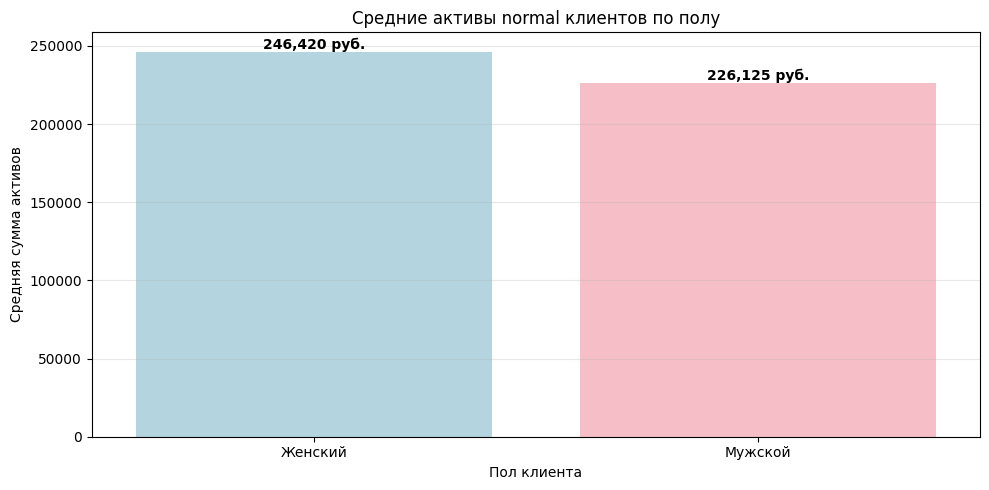

In [84]:
# Визуализация normal клиентов по полу
plt.figure(figsize=(10, 5))
sns.barplot(data=normal_df, x='gender', y='assets', hue='gender',
           estimator='mean', errorbar=None, palette=['lightblue', 'lightpink'], legend=False)
plt.title('Средние активы normal клиентов по полу')
plt.ylabel('Средняя сумма активов')
plt.xlabel('Пол клиента')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
ax = plt.gca()
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:,.0f} руб.', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

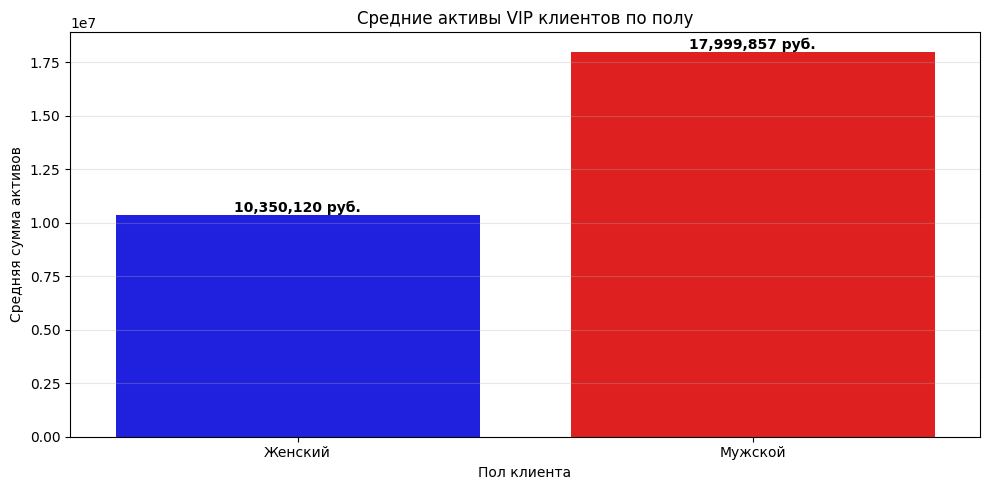

In [85]:
# Визуализация vip клиентов по полу
plt.figure(figsize=(10, 5))
sns.barplot(data=vip_df, x='gender', y='assets', hue='gender',
           estimator='mean', errorbar=None, palette=['blue', 'red'], legend=False)
plt.title('Средние активы VIP клиентов по полу')
plt.ylabel('Средняя сумма активов')
plt.xlabel('Пол клиента')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
ax = plt.gca()
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:,.0f} руб.', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [87]:
# Ещё статистика
print(f"Normal клиенты - Мужчины: {len(normal_df[normal_df['gender'] == 'Мужской']):,} чел.")
print(f"Normal клиенты - Женщины: {len(normal_df[normal_df['gender'] == 'Женский']):,} чел.")
print(f"VIP клиенты - Мужчины: {len(vip_df[vip_df['gender'] == 'Мужской']):,} чел.")
print(f"VIP клиенты - Женщины: {len(vip_df[vip_df['gender'] == 'Женский']):,} чел.")

# Соотношение активов
male_normal = normal_df[normal_df['gender'] == 'Мужской']['assets'].mean()
female_normal = normal_df[normal_df['gender'] == 'Женский']['assets'].mean()
male_vip = vip_df[vip_df['gender'] == 'Мужской']['assets'].mean()
female_vip = vip_df[vip_df['gender'] == 'Женский']['assets'].mean()

print(f"\nСоотношение активов мужчины/женщины:")
print(f"Normal: {male_normal/female_normal:.2f} раза")
print(f"VIP: {male_vip/female_vip:.2f} раза")

Normal клиенты - Мужчины: 443,635 чел.
Normal клиенты - Женщины: 332,177 чел.
VIP клиенты - Мужчины: 164,976 чел.
VIP клиенты - Женщины: 102,800 чел.

Соотношение активов мужчины/женщины:
Normal: 0.92 раза
VIP: 1.74 раза


##### Средняя сумма активов по возрастным группам и статусу:

In [89]:
# Средние активы по возрастным группам и статусу
age_status_assets = filtered_df.groupby(['age_group', 'status'], observed=False)['assets'].agg(['mean', 'median', 'count']).round(2)
print("\nСредние активы по возрастным группам и статусу:")
print(age_status_assets)

# Создаем два отдельных DataFrame для normal и vip клиентов
normal_df = filtered_df[filtered_df['status'] == 'normal']
vip_df = filtered_df[filtered_df['status'] == 'vip']


Средние активы по возрастным группам и статусу:
                         mean      median   count
age_group status                                 
18-30     normal    139641.39     9659.10  118580
          vip      7181878.29  3062115.40   17385
31-40     normal    216432.35    52449.60  235459
          vip     11650824.13  3410127.35   69414
41-50     normal    253635.94   101855.90  239613
          vip     14781735.11  3667786.90   89178
51-60     normal    279916.67   139641.30  118653
          vip     19743699.90  3338775.20   53637
61-70     normal    318002.12   193549.30   47807
          vip     21755113.44  3616320.15   29458
70+       normal    347893.44   207555.45   15700
          vip      9408188.81  3706362.60    8704


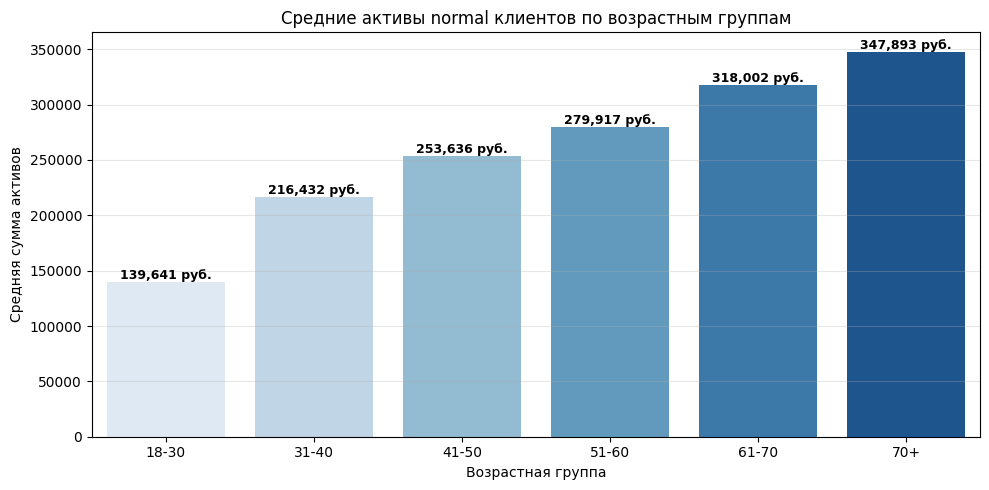

In [90]:
# Визуализация normal клиенты по возрастным группам
plt.figure(figsize=(10, 5))
sns.barplot(data=normal_df, x='age_group', y='assets', hue='age_group',
           estimator='mean', errorbar=None, palette='Blues', legend=False)
plt.title('Средние активы normal клиентов по возрастным группам')
plt.ylabel('Средняя сумма активов')
plt.xlabel('Возрастная группа')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
ax = plt.gca()
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:,.0f} руб.', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

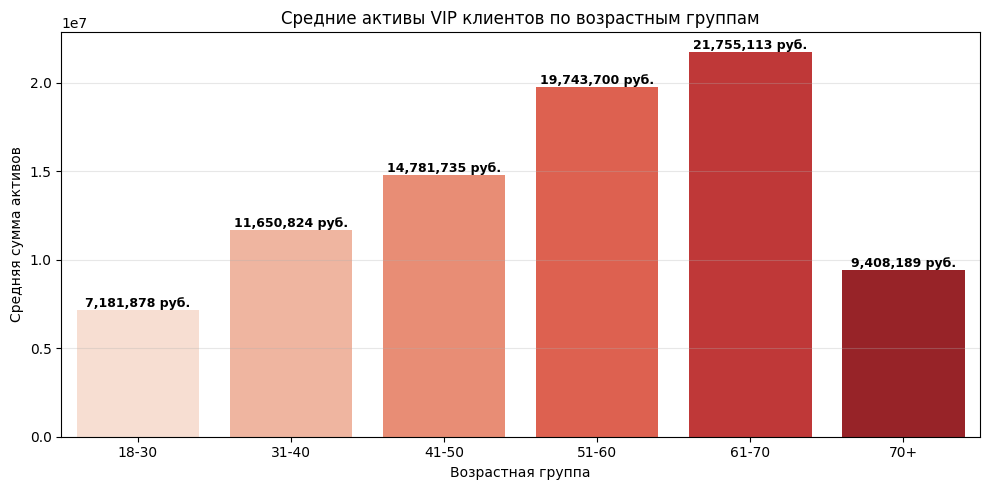

In [91]:
# Визуализация vip клиенты по возрастным группам
plt.figure(figsize=(10, 5))
sns.barplot(data=vip_df, x='age_group', y='assets', hue='age_group',
           estimator='mean', errorbar=None, palette='Reds', legend=False)
plt.title('Средние активы VIP клиентов по возрастным группам')
plt.ylabel('Средняя сумма активов')
plt.xlabel('Возрастная группа')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
ax = plt.gca()
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:,.0f} руб.', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [92]:
# Дополнительная статистика
print("\nКоличество клиентов по возрастным группам и статусу:")
age_status_count = filtered_df.groupby(['age_group', 'status'], observed=False).size().unstack()
print(age_status_count)


Количество клиентов по возрастным группам и статусу:
status     normal    vip
age_group               
18-30      118580  17385
31-40      235459  69414
41-50      239613  89178
51-60      118653  53637
61-70       47807  29458
70+         15700   8704


##### Средняя сумма активов по полу, возрастной группе и статусу(по сути, объединение первых двух пунктов):

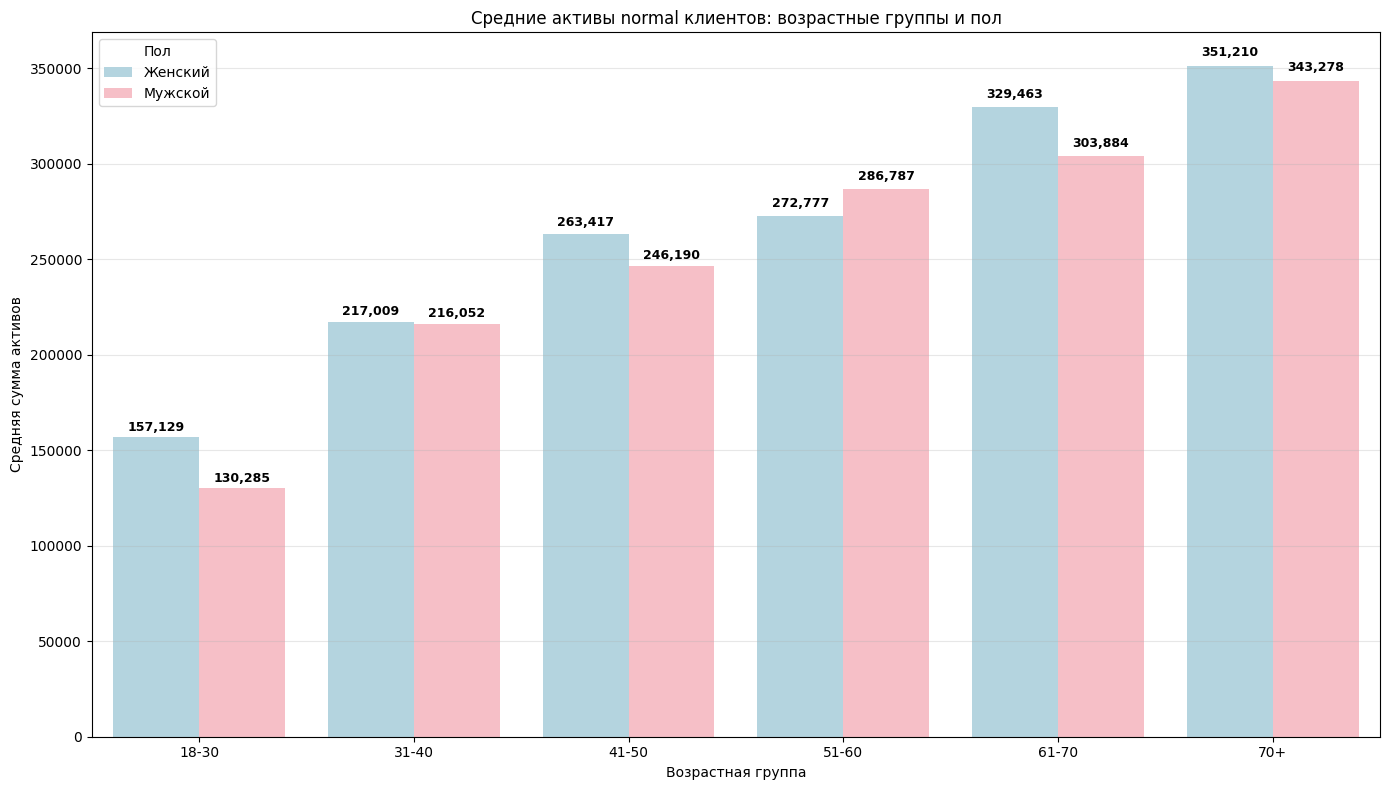

In [93]:
# Визуализация Normal клиенты
plt.figure(figsize=(14, 8))
ax1 = sns.barplot(data=normal_df, x='age_group', y='assets', hue='gender',
                 estimator='mean', errorbar=None, palette=['lightblue', 'lightpink'])
plt.title('Средние активы normal клиентов: возрастные группы и пол')
plt.ylabel('Средняя сумма активов')
plt.xlabel('Возрастная группа')
plt.legend(title='Пол')
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений для normal клиентов
for container in ax1.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Добавляем подписи только для положительных значений
            ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{height:,.0f}', ha='center', va='bottom', 
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

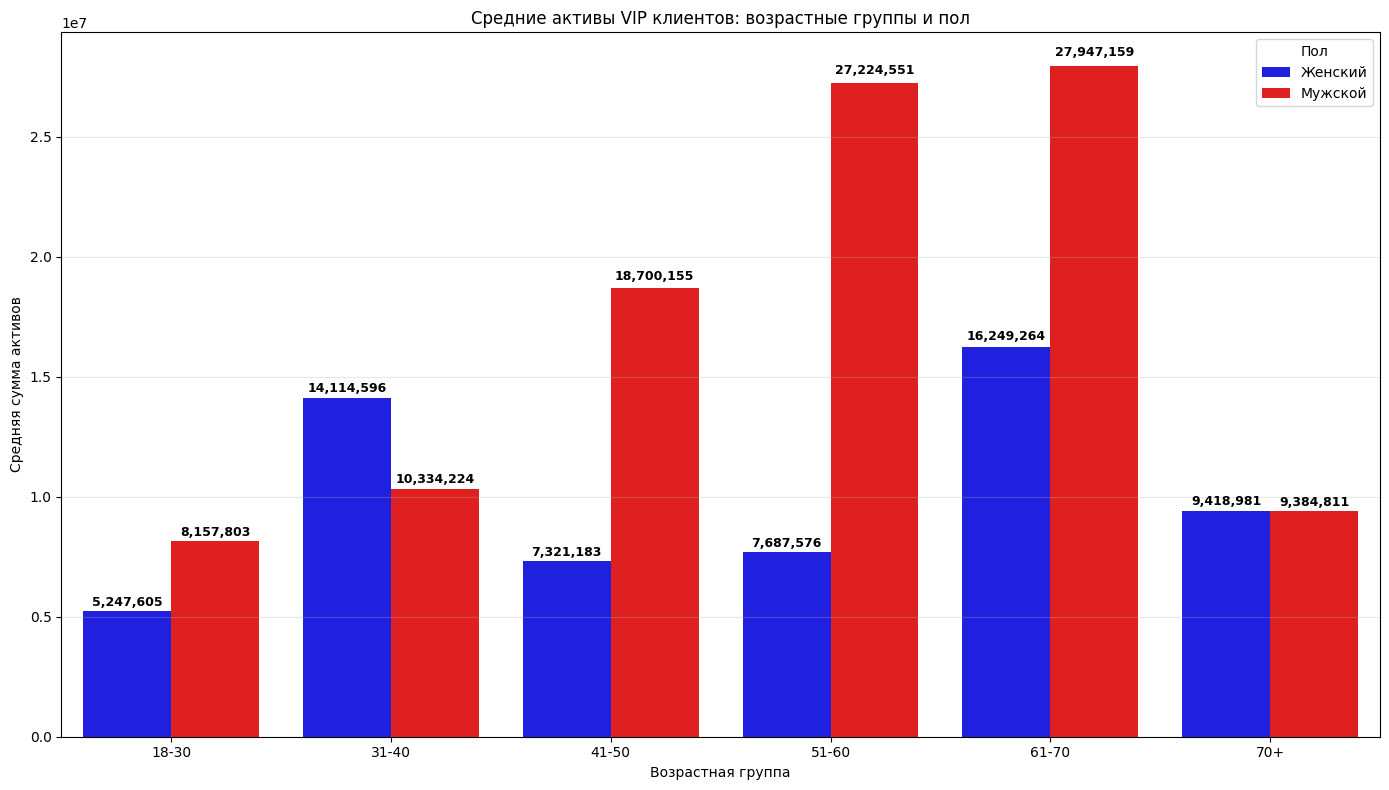

In [94]:
# Визуализация vip клиенты
plt.figure(figsize=(14, 8))
ax2 = sns.barplot(data=vip_df, x='age_group', y='assets', hue='gender',
                 estimator='mean', errorbar=None, palette=['blue', 'red'])
plt.title('Средние активы VIP клиентов: возрастные группы и пол')
plt.ylabel('Средняя сумма активов')
plt.xlabel('Возрастная группа')
plt.legend(title='Пол')
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений для vip клиентов
for container in ax2.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Добавляем подписи только для положительных значений
            ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{height:,.0f}', ha='center', va='bottom', 
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [95]:
# Детальная статистика по возрастным группам
print("\nКоличество клиентов в каждой из групп:")
detailed_stats = filtered_df.groupby(['status', 'age_group', 'gender'], observed=False)['assets'].count()
print(detailed_stats)


Количество клиентов в каждой из групп:
status  age_group  gender 
normal  18-30      Женский     41332
                   Мужской     77248
        31-40      Женский     93571
                   Мужской    141888
        41-50      Женский    103564
                   Мужской    136049
        51-60      Женский     58188
                   Мужской     60465
        61-70      Женский     26387
                   Мужской     21420
        70+        Женский      9135
                   Мужской      6565
vip     18-30      Женский      5830
                   Мужской     11555
        31-40      Женский     24175
                   Мужской     45239
        41-50      Женский     30709
                   Мужской     58469
        51-60      Женский     20538
                   Мужской     33099
        61-70      Женский     15593
                   Мужской     13865
        70+        Женский      5955
                   Мужской      2749
Name: assets, dtype: int64


In [74]:
# Дополнительная информация о соотношении активов мужчин и женщин
print("\nСоотношение активов мужчин и женщин по возрастным группам:")

for status in ['normal', 'vip']:
    status_df = filtered_df[filtered_df['status'] == status]
    ratio_stats = []
    
    for age_group in sorted(status_df['age_group'].unique()):
        group_df = status_df[status_df['age_group'] == age_group]
        male_mean = group_df[group_df['gender'] == 'Мужской']['assets'].mean()
        female_mean = group_df[group_df['gender'] == 'Женский']['assets'].mean()
        
        if pd.notna(male_mean) and pd.notna(female_mean) and female_mean > 0:
            ratio = male_mean / female_mean
            ratio_stats.append((age_group, ratio))
    
    print(f"\n{status.upper()} клиенты - соотношение М/Ж:")
    for age_group, ratio in ratio_stats:
        print(f"{age_group}: {ratio:.2f} раза")


Соотношение активов мужчин и женщин по возрастным группам:

NORMAL клиенты - соотношение М/Ж:
18-30: 0.83 раза
31-40: 1.00 раза
41-50: 0.93 раза
51-60: 1.05 раза
61-70: 0.92 раза
70+: 0.98 раза

VIP клиенты - соотношение М/Ж:
18-30: 1.55 раза
31-40: 0.73 раза
41-50: 2.55 раза
51-60: 3.54 раза
61-70: 1.72 раза
70+: 1.00 раза


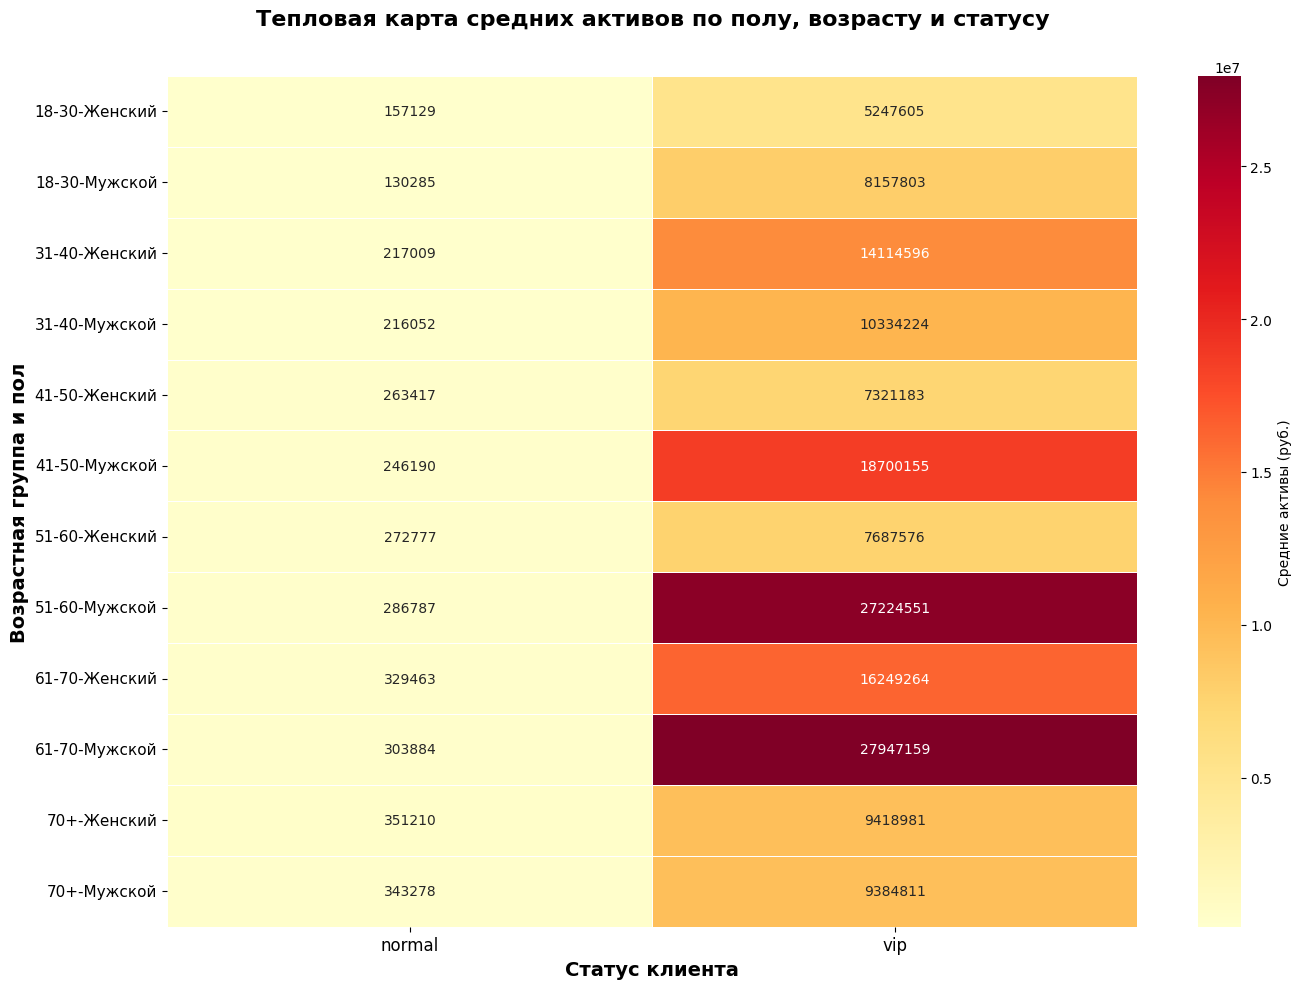

In [96]:
# Тепловая карта средних активов
pivot_table = filtered_df.pivot_table(
    values='assets', 
    index=['age_group', 'gender'], 
    columns='status', 
    aggfunc='mean',
    observed=False  # Добавляем параметр observed
).round(2)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', 
           cbar_kws={'label': 'Средние активы (руб.)'}, 
           linewidths=0.5, linecolor='white')
plt.title('Тепловая карта средних активов по полу, возрасту и статусу\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Статус клиента', fontsize=14, fontweight='bold')
plt.ylabel('Возрастная группа и пол', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

In [97]:
# Находим группы с максимальными активами
max_vip = pivot_table['vip'].max()
max_vip_index = pivot_table['vip'].idxmax()
max_normal = pivot_table['normal'].max()
max_normal_index = pivot_table['normal'].idxmax()

print(f"\nМаксимальные средние активы:")
print(f"VIP: {max_vip:,.0f} руб. ({max_vip_index[1]} {max_vip_index[0]})")
print(f"Normal: {max_normal:,.0f} руб. ({max_normal_index[1]} {max_normal_index[0]})")

# Анализ по полу
gender_stats = filtered_df.groupby(['gender', 'status'], observed=False)['assets'].mean().unstack()
print(f"\nСредние активы по полу:")
print(f"Мужчины - VIP: {gender_stats.loc['Мужской', 'vip']:,.0f} руб.")
print(f"Мужчины - Normal: {gender_stats.loc['Мужской', 'normal']:,.0f} руб.")
print(f"Женщины - VIP: {gender_stats.loc['Женский', 'vip']:,.0f} руб.")
print(f"Женщины - Normal: {gender_stats.loc['Женский', 'normal']:,.0f} руб.")


Максимальные средние активы:
VIP: 27,947,159 руб. (Мужской 61-70)
Normal: 351,210 руб. (Женский 70+)

Средние активы по полу:
Мужчины - VIP: 17,999,857 руб.
Мужчины - Normal: 226,125 руб.
Женщины - VIP: 10,350,120 руб.
Женщины - Normal: 246,420 руб.


#### Анализ средней доходности по клинетам в зависимости от статуса, пола и возраста.

##### Подготавливаем данные

Добавим условия фильтрации:
- `df['assets'] > 0]` - то есть, сумма на балансе положительная
- `df['birth_date'] < 2004` - то есть, все клиенты старше 18 лет
- `df['gender']  > 0` - фильтруем значение заглушку `-1`
- `df[yields] > -100` - фильтруем по минимально допустимому для нас занчению
- `std` для каждого клиента `client_id` по полю `df[yields] < 660` - фильтруем по максимально допустимому для нас значению

In [98]:
# Применяем фильтрацию
filtered_yields_df = df[
    (df['assets'] > 0) & 
    (df['birth_date'] < pd.to_datetime('2004-01-01')) & 
    (df['gender'] > 0) &
    (df['yields'] > -100)
].copy()

# Рассчитываем стандартное отклонение доходности для каждого клиента для будующей фильтрации
client_std = filtered_yields_df.groupby('client_id')['yields'].std()

# Фильтруем клиентов с std < 660
valid_clients = client_std[client_std < 660].index
filtered_yields_df = filtered_yields_df[filtered_yields_df['client_id'].isin(valid_clients)]

In [99]:
# Рассчитываем возраст клиентов
filtered_yields_df['age'] = ((filtered_yields_df['datepost'] - filtered_yields_df['birth_date']).dt.days / 365.25).astype(int)

# Создаем возрастные группы
filtered_yields_df['age_group'] = pd.cut(filtered_yields_df['age'], 
                                       bins=[18, 30, 40, 50, 60, 70, 100],
                                       labels=['18-30', '31-40', '41-50', '51-60', '61-70', '70+'])

# Преобразуем пол в категориальный признак
filtered_yields_df['gender'] = filtered_yields_df['gender'].map({1: 'Мужской', 2: 'Женский'})

##### Средняя доходность по статусу:

In [100]:
# Анализ средней доходности по статусу
print(f"Количество клиентов после фильтрации: {filtered_yields_df['client_id'].nunique():,}")
print(f"Количество наблюдений: {len(filtered_yields_df):,}")

# Средняя доходность по статусу
status_yields = filtered_yields_df.groupby('status', observed=False)['yields'].agg(['mean', 'median', 'std', 'count']).round(2)
print("\nДоходность по статусу:")
print(status_yields)

Количество клиентов после фильтрации: 13,218
Количество наблюдений: 1,041,918

Доходность по статусу:
        mean  median    std   count
status                             
normal -5.77    -0.6  28.22  774461
vip     0.22    -0.1  22.41  267457


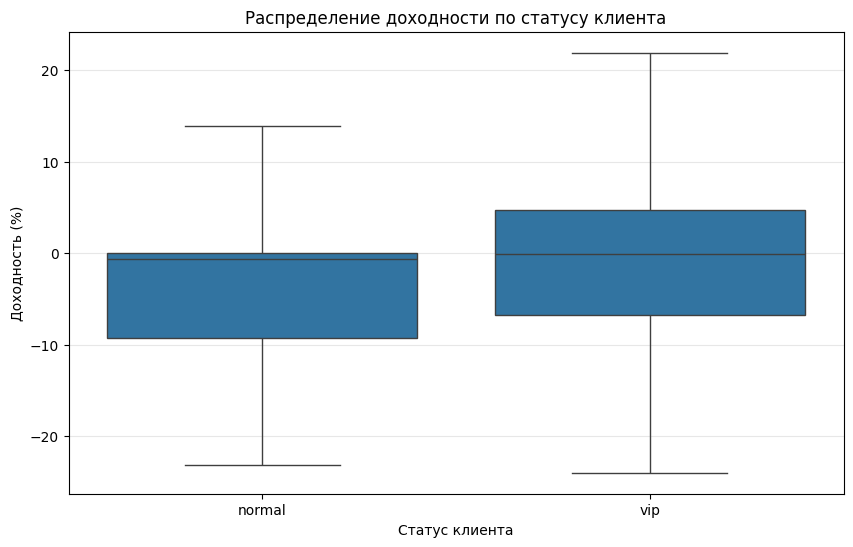

In [101]:
# Визуализируем
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_yields_df, x='status', y='yields', showfliers=False)
plt.title('Распределение доходности по статусу клиента')
plt.ylabel('Доходность (%)')
plt.xlabel('Статус клиента')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Средняя доходность по полу

In [103]:
# Анализ по полу и статусу
gender_status_yields = filtered_yields_df.groupby(['gender', 'status'], observed=False)['yields'].agg(['mean', 'median', 'count']).round(2)
print("\nДоходность по полу и статусу:")
print(gender_status_yields)


Доходность по полу и статусу:
                mean  median   count
gender  status                      
Женский normal -5.84    -1.4  331644
        vip    -0.24     0.0  102613
Мужской normal -5.72     0.0  442817
        vip     0.51    -0.1  164844


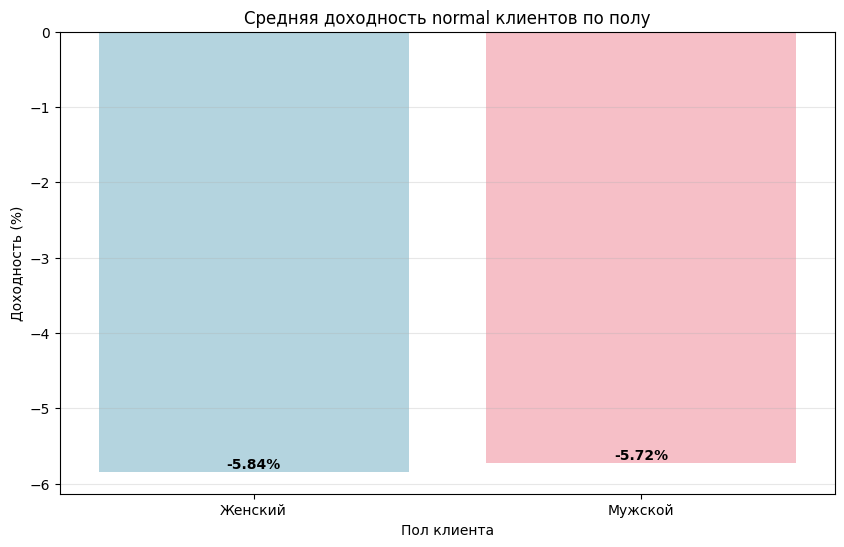

In [104]:
# Визуализируем normal клиенты по полу
normal_yields = filtered_yields_df[filtered_yields_df['status'] == 'normal']
plt.figure(figsize=(10, 6))
sns.barplot(data=normal_yields, x='gender', y='yields', hue='gender',
           estimator='mean', errorbar=None, palette=['lightblue', 'lightpink'], legend=False)
plt.title('Средняя доходность normal клиентов по полу')
plt.ylabel('Доходность (%)')
plt.xlabel('Пол клиента')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
ax = plt.gca()
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.show()

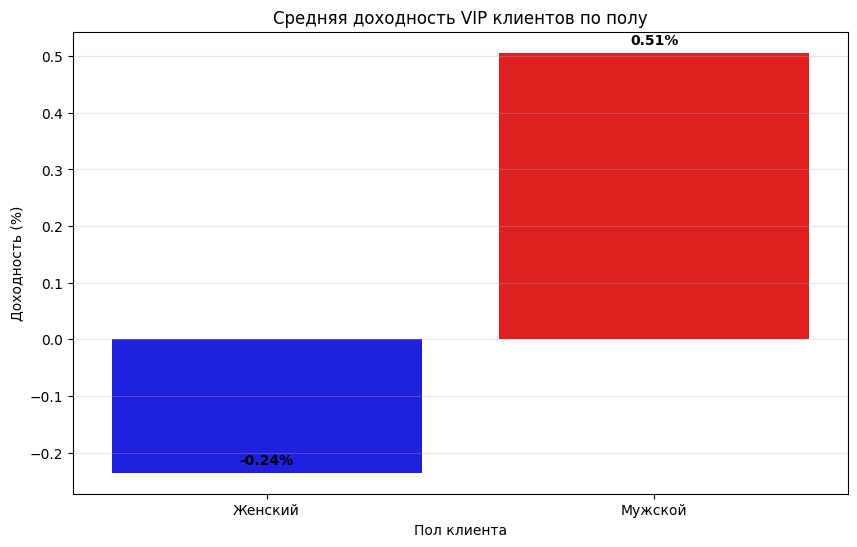

In [105]:
# Визуализируем vip клиенты по полу
vip_yields = filtered_yields_df[filtered_yields_df['status'] == 'vip']
plt.figure(figsize=(10, 6))
sns.barplot(data=vip_yields, x='gender', y='yields', hue='gender',
           estimator='mean', errorbar=None, palette=['blue', 'red'], legend=False)
plt.title('Средняя доходность VIP клиентов по полу')
plt.ylabel('Доходность (%)')
plt.xlabel('Пол клиента')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
ax = plt.gca()
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.show()

##### Средняя доходность по статусу и возрасту

In [106]:
# Анализ по возрастным группам
age_status_yields = filtered_yields_df.groupby(['age_group', 'status'], observed=False)['yields'].agg(['mean', 'median', 'count']).round(2)
print("\nДоходность по возрастным группам и статусу:")
print(age_status_yields)


Доходность по возрастным группам и статусу:
                  mean  median   count
age_group status                      
18-30     normal -3.80     0.0  118558
          vip    -0.59    -0.1   17318
31-40     normal -5.74    -0.1  234952
          vip     0.49     0.0   69352
41-50     normal -6.62    -1.5  239128
          vip    -0.50    -0.1   89071
51-60     normal -6.76    -1.8  118453
          vip     0.98     0.0   53590
61-70     normal -5.02    -1.8   47695
          vip     0.97    -0.3   29422
70+       normal -3.23    -1.5   15675
          vip    -0.11    -0.2    8704


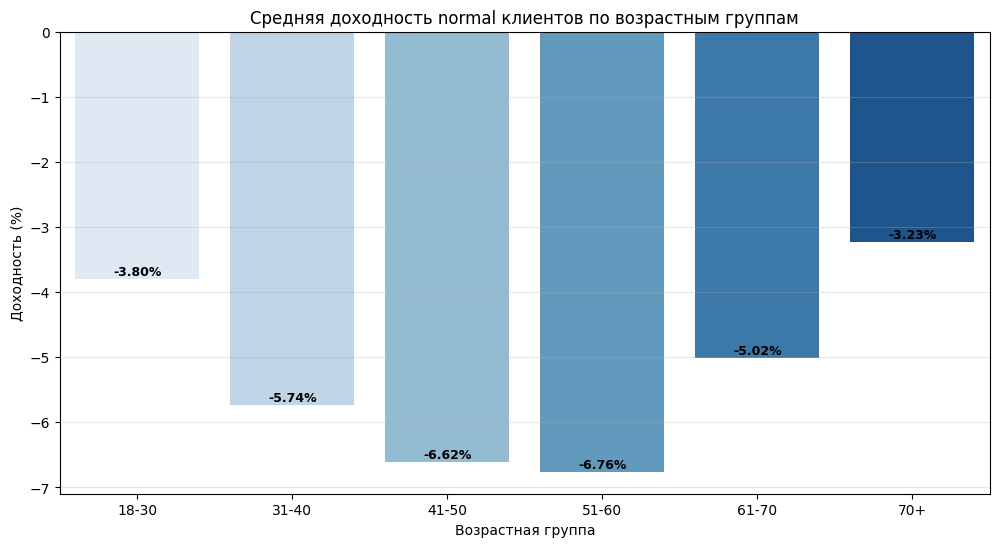

In [107]:
# Визуализация normal клиенты по возрастным группам
plt.figure(figsize=(12, 6))
sns.barplot(data=normal_yields, x='age_group', y='yields', hue='age_group',
           estimator='mean', errorbar=None, palette='Blues', legend=False)
plt.title('Средняя доходность normal клиентов по возрастным группам')
plt.ylabel('Доходность (%)')
plt.xlabel('Возрастная группа')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
ax = plt.gca()
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.show()

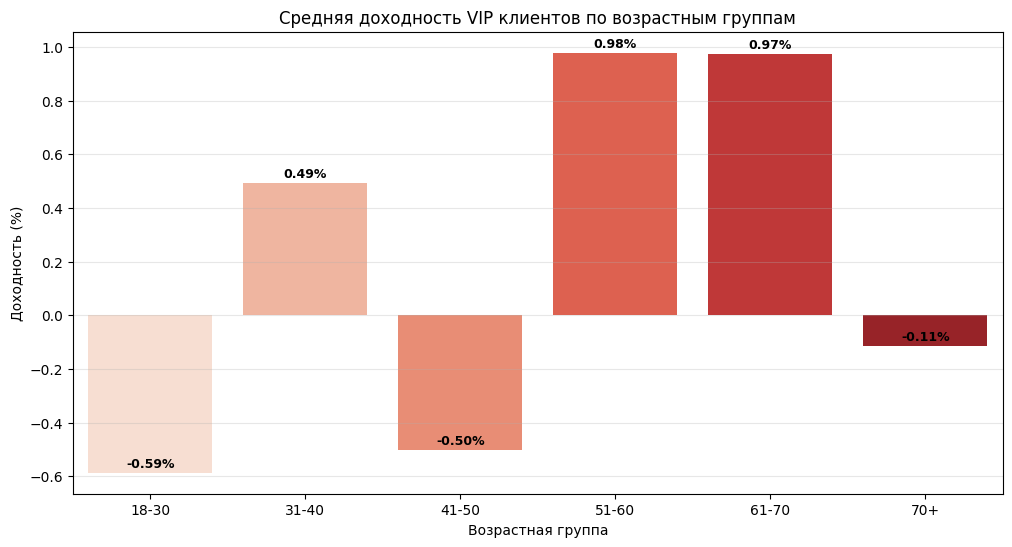

In [108]:
# Визуализируем vip клиенты по возрастным группам
plt.figure(figsize=(12, 6))
sns.barplot(data=vip_yields, x='age_group', y='yields', hue='age_group',
           estimator='mean', errorbar=None, palette='Reds', legend=False)
plt.title('Средняя доходность VIP клиентов по возрастным группам')
plt.ylabel('Доходность (%)')
plt.xlabel('Возрастная группа')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
ax = plt.gca()
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.show()

##### Средняя доходность по статусу, полу и возрасту (по сути, объединение первых трёх пунктов):

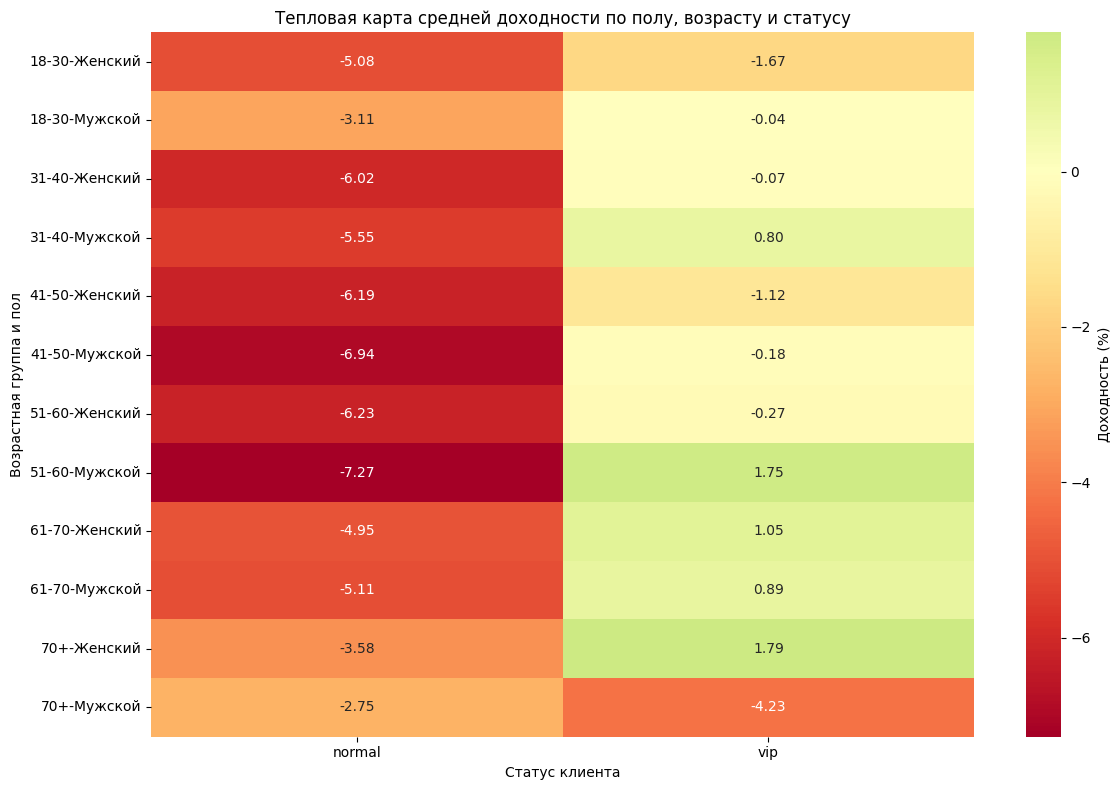

In [110]:
# Тепловая карта средней доходности
pivot_yields = filtered_yields_df.pivot_table(
    values='yields', 
    index=['age_group', 'gender'], 
    columns='status', 
    aggfunc='mean',
    observed=False
).round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_yields, annot=True, fmt='.2f', cmap='RdYlGn', 
           center=0, cbar_kws={'label': 'Доходность (%)'})
plt.title('Тепловая карта средней доходности по полу, возрасту и статусу')
plt.xlabel('Статус клиента')
plt.ylabel('Возрастная группа и пол')
plt.tight_layout()
plt.show()

In [113]:
# Ещё информация
print(f"Общая средняя доходность: {filtered_yields_df['yields'].mean():.2f}%")
print(f"Медианная доходность: {filtered_yields_df['yields'].median():.2f}%")

max_yields_status = status_yields['mean'].idxmax()
max_yields_value = status_yields['mean'].max()
print(f"Наивысшая средняя доходность у клиентов статуса: {max_yields_status} ({max_yields_value:.2f}%)")

# Анализ по возрастным группам
age_group_stats = filtered_yields_df.groupby('age_group', observed=False)['yields'].mean().sort_values(ascending=False)
best_age_group = age_group_stats.index[0]
best_age_yield = age_group_stats.iloc[0]
print(f"Наивысшая средняя доходность у клиентов в возрастной группе: {best_age_group} ({best_age_yield:.2f}%)")

Общая средняя доходность: -4.23%
Медианная доходность: -0.40%
Наивысшая средняя доходность у клиентов статуса: vip (0.22%)
Наивысшая средняя доходность у клиентов в возрастной группе: 70+ (-2.12%)


#### Анализ сумм вводов/выводов у клиентов в зависимости от статуса, пола и возраста.

##### Подготавливаем данные

Добавим условия фильтрации:
- `df['gender'] > 0` - фильтруем значение заглушку `-1`
- заменим пропуски в столбцах 'money_in' и 'money_out' на `0`
- `df['money_in'] > 0` - фильтруем значение заглушку `0`
- `df['money_out'] > 0` - фильтруем значение заглушку `0`

In [118]:
# ПОДГОТАВЛИВАЕМ ДАННЫЕ И ФИЛЬТРУЕМ 

# Создаем копию
money_df = df.copy()

# Заменяем nan в money_in и money_out на 0
money_df['money_in'] = money_df['money_in'].fillna(0)
money_df['money_out'] = money_df['money_out'].fillna(0)

# Применяем все фильтры последовательно
money_df = money_df[money_df['gender'] > 0]  # Фильтруем заглушки
money_df = money_df[money_df['money_in'] > 0]  # Только с вводами
money_df = money_df[money_df['money_out'] > 0]  # Только с выводами

# Рассчитываем возраст клиентов
money_df['age'] = ((money_df['datepost'] - money_df['birth_date']).dt.days / 365.25).astype(int)

# Создаем возрастные группы
money_df['age_group'] = pd.cut(money_df['age'], 
                              bins=[0, 18, 30, 40, 50, 60, 70, 100],
                              labels=['0-18', '19-30', '31-40', '41-50', '51-60', '61-70', '70+'])

# Преобразуем пол признак
money_df['gender'] = money_df['gender'].map({1: 'Мужской', 2: 'Женский'})

# Рассчитываем чистый поток средств
money_df['net_flow'] = money_df['money_in'] - money_df['money_out']

print(f"Общее кол-во клиентов: {money_df['client_id'].nunique():,}")
print(f"Общее кол-во строк: {len(money_df):,}")

Общее кол-во клиентов: 210
Общее кол-во строк: 291


##### Показатели в зависимости от статуса:

In [120]:
# Группируем
status_money = money_df.groupby('status', observed=False).agg({
    'money_in': ['sum', 'mean', 'count'],
    'money_out': ['sum', 'mean'],
    'net_flow': ['sum', 'mean']
}).round(2)

# Смотрим
display(status_money)

money_in                       money_out              \
                 sum        mean count           sum        mean   
status                                                             
normal  2.483104e+07   161240.53   154  1.343356e+08   872309.32   
vip     2.487548e+08  1815728.63   137  2.523673e+08  1842096.94   

            net_flow             
                 sum       mean  
status                           
normal -1.095046e+08 -711068.79  
vip    -3.612459e+06  -26368.31

##### Показатели в зависимости от пола:

In [121]:
# Группируем
gender_money = money_df.groupby('gender', observed=False).agg({
    'money_in': ['sum', 'mean', 'count'],
    'money_out': ['sum', 'mean'],
    'net_flow': ['sum', 'mean']
}).round(2)

# Смотрим
display(gender_money)

money_in                      money_out                 net_flow  \
                  sum       mean count           sum        mean          sum   
gender                                                                          
Женский  1.349887e+08  978178.70   138  1.834240e+08  1329159.48 -48435347.06   
Мужской  1.385972e+08  905864.06   153  2.032789e+08  1328620.31 -64681706.04   

                    
              mean  
gender              
Женский -350980.78  
Мужской -422756.25

##### Показатели в зависимости от возраста:

In [122]:
# Группируем
age_money = money_df.groupby('age_group', observed=False).agg({
    'money_in': ['sum', 'mean', 'count'],
    'money_out': ['sum', 'mean'],
    'net_flow': ['sum', 'mean']
}).round(2)

# Смотрим
display(age_money)

money_in                       money_out              \
                    sum        mean count           sum        mean   
age_group                                                             
0-18       2.436499e+06   487299.72     5  8.924336e+05   178486.71   
19-30      2.780412e+07   556082.34    50  3.133192e+07   626638.45   
31-40      1.039772e+08   825215.75   126  1.534627e+08  1217958.08   
41-50      9.367275e+07  1200932.73    78  1.345580e+08  1725103.05   
51-60      6.241836e+06   367166.82    17  2.850887e+07  1676992.10   
61-70      3.476205e+07  3862449.68     9  3.348671e+07  3720745.41   
70+        4.691427e+06   781904.48     6  4.462230e+06   743704.92   

              net_flow              
                   sum        mean  
age_group                           
0-18        1544065.03   308813.01  
19-30      -3527805.56   -70556.11  
31-40     -49485533.73  -392742.33  
41-50     -40885284.92  -524170.32  
51-60     -22267029.69 -1309825.28  
61-70       1275338.45   141704.27  
70+          229197.31    38199.55

##### Визуализации рассчётов

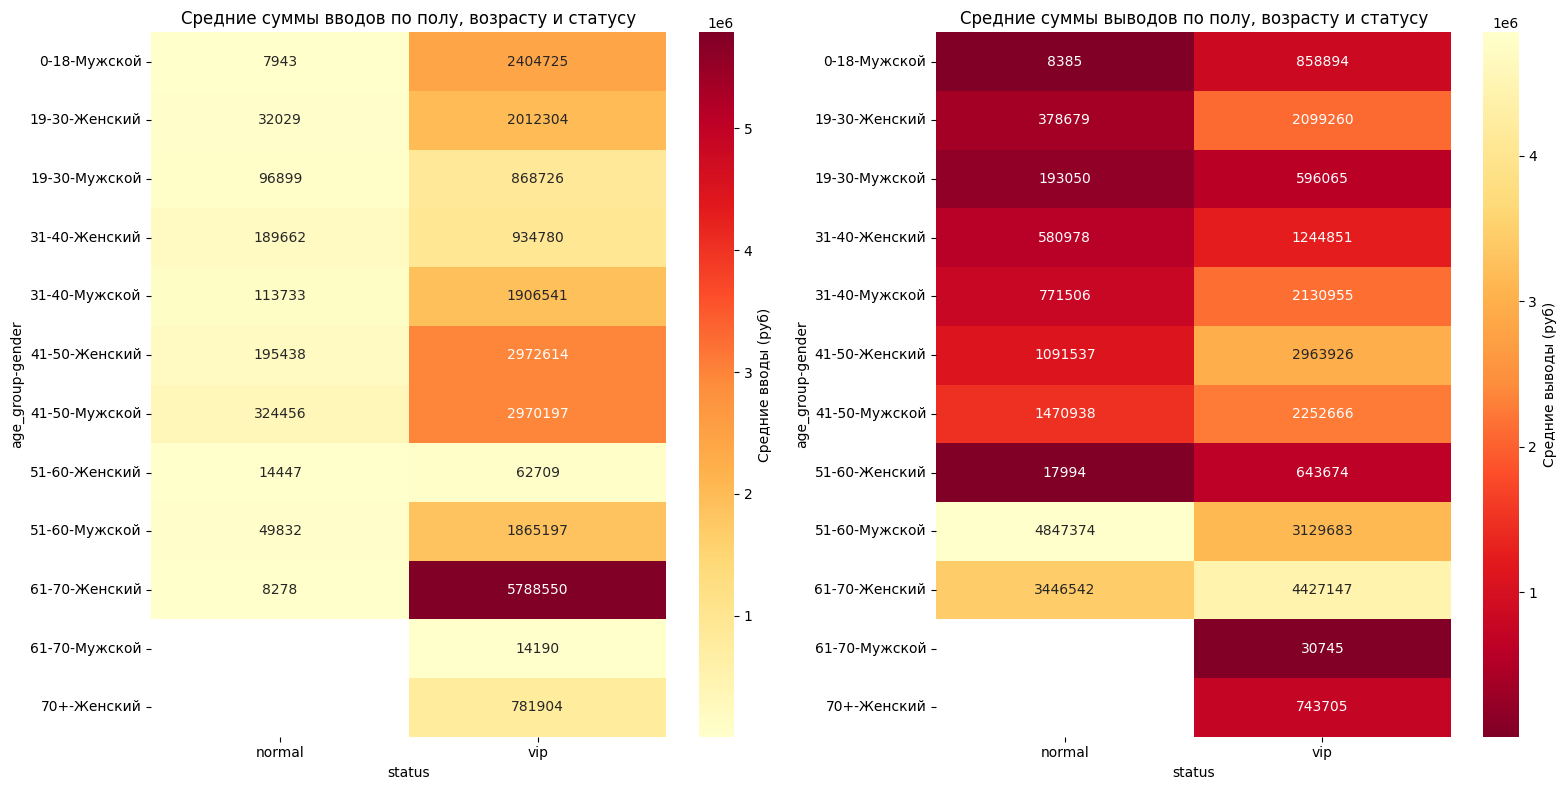

In [123]:
# Визуализируем результаты
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Тепловая карта средних вводов
pivot_in = money_df.pivot_table(values='money_in', index=['age_group', 'gender'], 
                                 columns='status', aggfunc='mean', observed=False).round(2)
sns.heatmap(pivot_in, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0], 
            cbar_kws={'label': 'Средние вводы (руб)'})
axes[0].set_title('Средние суммы вводов по полу, возрасту и статусу')

# Тепловая карта средних выводов
pivot_out = money_df.pivot_table(values='money_out', index=['age_group', 'gender'], 
                                  columns='status', aggfunc='mean', observed=False).round(2)
sns.heatmap(pivot_out, annot=True, fmt='.0f', cmap='YlOrRd_r', ax=axes[1], 
            cbar_kws={'label': 'Средние выводы (руб)'})
axes[1].set_title('Средние суммы выводов по полу, возрасту и статусу')

# Смотрим
plt.tight_layout()
plt.show()

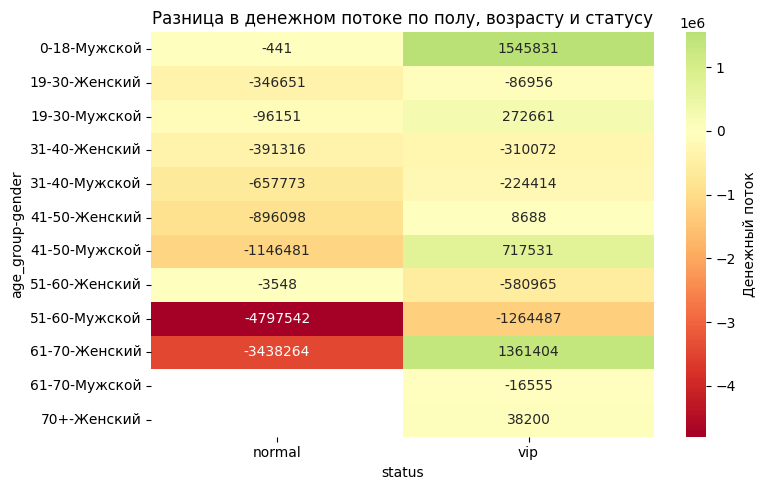

In [124]:
# Визуализируем разницу в денежном потоке
plt.figure(figsize=(8, 5))

# Создаем сводную таблицу
pivot_net = money_df.pivot_table(values='net_flow', index=['age_group', 'gender'], 
                                  columns='status', aggfunc='mean', observed=False).round(2)

# Строим тепловую карту
sns.heatmap(pivot_net, annot=True, fmt='.0f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Денежный поток'})

# Устанавливаем заголовок
plt.title('Разница в денежном потоке по полу, возрасту и статусу')

# Показываем график
plt.tight_layout()
plt.show()

##### Итоговые метрики:

In [126]:
# Соотношение вводов/выводов по статусу
for status in money_df['status'].unique():
    status_df = money_df[money_df['status'] == status]
    total_in = status_df['money_in'].sum()
    total_out = status_df['money_out'].sum()
    ratio = total_in / total_out if total_out > 0 else float('inf')
    print(f"\nКлиенты статуса {status}:")
    print(f"Всего вводов: {total_in:,.0f} руб.")
    print(f"Всего выводов: {total_out:,.0f} руб.")
    print(f"Соотношение вводы/выводы: {ratio:.2f}")


Клиенты статуса vip:
Всего вводов: 248,754,822 руб.
Всего выводов: 252,367,281 руб.
Соотношение вводы/выводы: 0.99

Клиенты статуса normal:
Всего вводов: 24,831,041 руб.
Всего выводов: 134,335,635 руб.
Соотношение вводы/выводы: 0.18


In [127]:
# Сравнительный анализ мужчин и женщин

male_stats = money_df[money_df['gender'] == 'Мужской']
female_stats = money_df[money_df['gender'] == 'Женский']

print(f"Мужчины: {len(male_stats):,} наблюдений, {male_stats['client_id'].nunique():,} клиентов")
print(f"Женщины: {len(female_stats):,} наблюдений, {female_stats['client_id'].nunique():,} клиентов")

print(f"\nСредняя сумма ввода:")
print(f"  Мужчины: {male_stats['money_in'].mean():.2f} руб.")
print(f"  Женщины: {female_stats['money_in'].mean():.2f} руб.")

print(f"\nСредняя сумма вывода:")
print(f"  Мужчины: {male_stats['money_out'].mean():.2f} руб.")
print(f"  Женщины: {female_stats['money_out'].mean():.2f} руб.")

print(f"\nСредний денежный поток:")
print(f"  Мужчины: {male_stats['net_flow'].mean():.2f} руб.")
print(f"  Женщины: {female_stats['net_flow'].mean():.2f} руб.")

Мужчины: 153 наблюдений, 116 клиентов
Женщины: 138 наблюдений, 94 клиентов

Средняя сумма ввода:
  Мужчины: 905864.06 руб.
  Женщины: 978178.70 руб.

Средняя сумма вывода:
  Мужчины: 1328620.31 руб.
  Женщины: 1329159.48 руб.

Средний денежный поток:
  Мужчины: -422756.25 руб.
  Женщины: -350980.78 руб.


### 3. Ключевые метрики для мониторинга

#### Соотношение активов в зависимости от статуса клинета

- **Почему важно**: VIP клиенты приносят имеют подовляющую долю активов
- **Цель**: Уменьшение нынешней пропорции в сторону клиентов статуса `normal` и усилия по удержанию клиентов статуса `vip`.
- **Действия**: Персональный менеджмент, премиальные услуги, целевые программы лояльности.

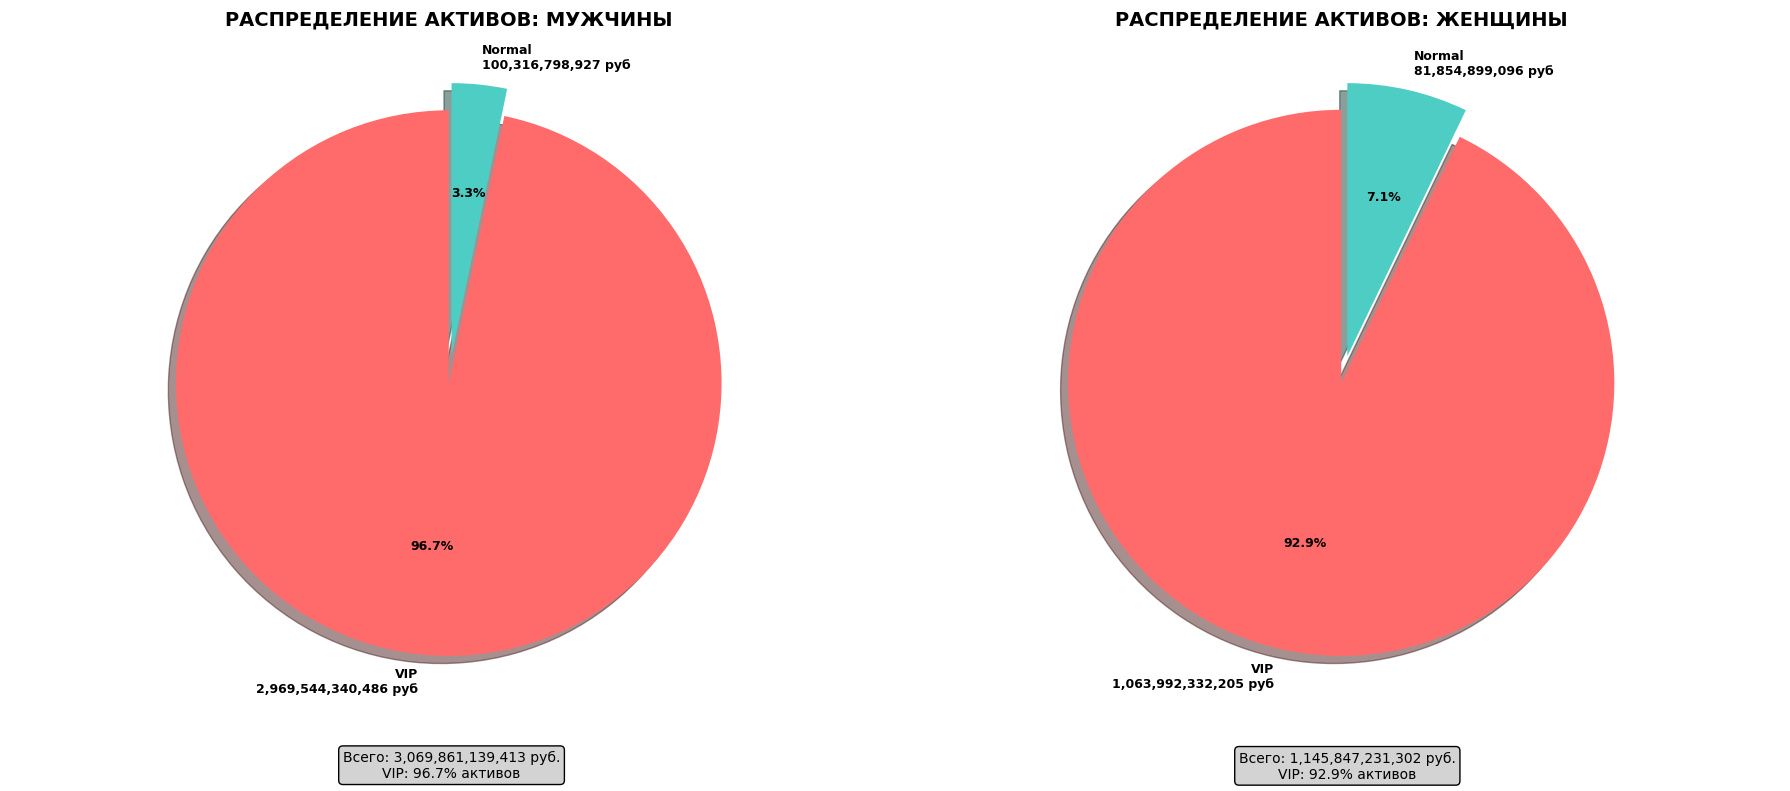

In [128]:
# ВИЗУАЛИЗАЦИЯ МЕТРИКИ
# Данные из предыдущих расчётов 
gender_stats = filtered_df.groupby(['gender', 'status'], observed=False)['assets'].sum().unstack()

# Извлекаем данные для визуализации
male_vip = gender_stats.loc['Мужской', 'vip']
male_normal = gender_stats.loc['Мужской', 'normal']
female_vip = gender_stats.loc['Женский', 'vip']
female_normal = gender_stats.loc['Женский', 'normal']

# Создаем диаграммы с двумя subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Круговая диаграмма для мужчин
male_labels = [f'VIP\n{male_vip:,.0f} руб', f'Normal\n{male_normal:,.0f} руб']
male_sizes = [male_vip, male_normal]
male_colors = ['#FF6B6B', '#4ECDC4']
male_explode = (0.1, 0)  # Выделяем VIP сегмент

ax1.pie(male_sizes, explode=male_explode, labels=male_labels, colors=male_colors,
        autopct='%1.1f%%', shadow=True, startangle=90, 
        textprops={'fontsize': 9, 'fontweight': 'bold'})
ax1.set_title('РАСПРЕДЕЛЕНИЕ АКТИВОВ: МУЖЧИНЫ\n', fontweight='bold', fontsize=14)
ax1.axis('equal')

# Добавляем подписи
total_male = male_vip + male_normal
vip_share_male = (male_vip / total_male) * 100
ax1.text(0, -1.5, f'Всего: {total_male:,.0f} руб.\nVIP: {vip_share_male:.1f}% активов', 
         ha='center', va='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

# Круговая диаграмма для женщин
female_labels = [f'VIP\n{female_vip:,.0f} руб', f'Normal\n{female_normal:,.0f} руб']
female_sizes = [female_vip, female_normal]
female_colors = ['#FF6B6B', '#4ECDC4']
female_explode = (0.1, 0)  # Выделяем VIP сегмент

ax2.pie(female_sizes, explode=female_explode, labels=female_labels, colors=female_colors,
        autopct='%1.1f%%', shadow=True, startangle=90, 
        textprops={'fontsize': 9, 'fontweight': 'bold'})
ax2.set_title('РАСПРЕДЕЛЕНИЕ АКТИВОВ: ЖЕНЩИНЫ\n', fontweight='bold', fontsize=14)
ax2.axis('equal')

# Добавляем подписи
total_female = female_vip + female_normal
vip_share_female = (female_vip / total_female) * 100
ax2.text(0, -1.5, f'Всего: {total_female:,.0f} руб.\nVIP: {vip_share_female:.1f}% активов', 
         ha='center', va='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

# Смотрим
plt.tight_layout()
plt.show()

In [129]:
print(f"\nМУЖЧИНЫ:")
print(f"VIP клиенты: {male_vip:,.0f} руб. ({vip_share_male:.1f}% от всех активов мужчин)")
print(f"Normal клиенты: {male_normal:,.0f} руб. ({100-vip_share_male:.1f}% от всех активов мужчин)")
print(f"Соотношение VIP/Normal: {male_vip/male_normal:.2f}:1")

print(f"\nЖЕНЩИНЫ:")
print(f"VIP клиенты: {female_vip:,.0f} руб. ({vip_share_female:.1f}% от всех активов женщин)")
print(f"Normal клиенты: {female_normal:,.0f} руб. ({100-vip_share_female:.1f}% от всех активов женщин)")
print(f"Соотношение VIP/Normal: {female_vip/female_normal:.2f}:1")


МУЖЧИНЫ:
VIP клиенты: 2,969,544,340,486 руб. (96.7% от всех активов мужчин)
Normal клиенты: 100,316,798,927 руб. (3.3% от всех активов мужчин)
Соотношение VIP/Normal: 29.60:1

ЖЕНЩИНЫ:
VIP клиенты: 1,063,992,332,205 руб. (92.9% от всех активов женщин)
Normal клиенты: 81,854,899,096 руб. (7.1% от всех активов женщин)
Соотношение VIP/Normal: 13.00:1


#### Соотношение активов в зависимости от возрастной группы

- **Почему важно**: Пик накоплений 50-70 лет у мужчин и 60-70 лет у женщин
- **Цель**: Стимуляция клиентов (50+) к увеличению накоплений.
- **Действия**: Пенсионные программы, консервативные стратегии инвестирования, персональные программы.

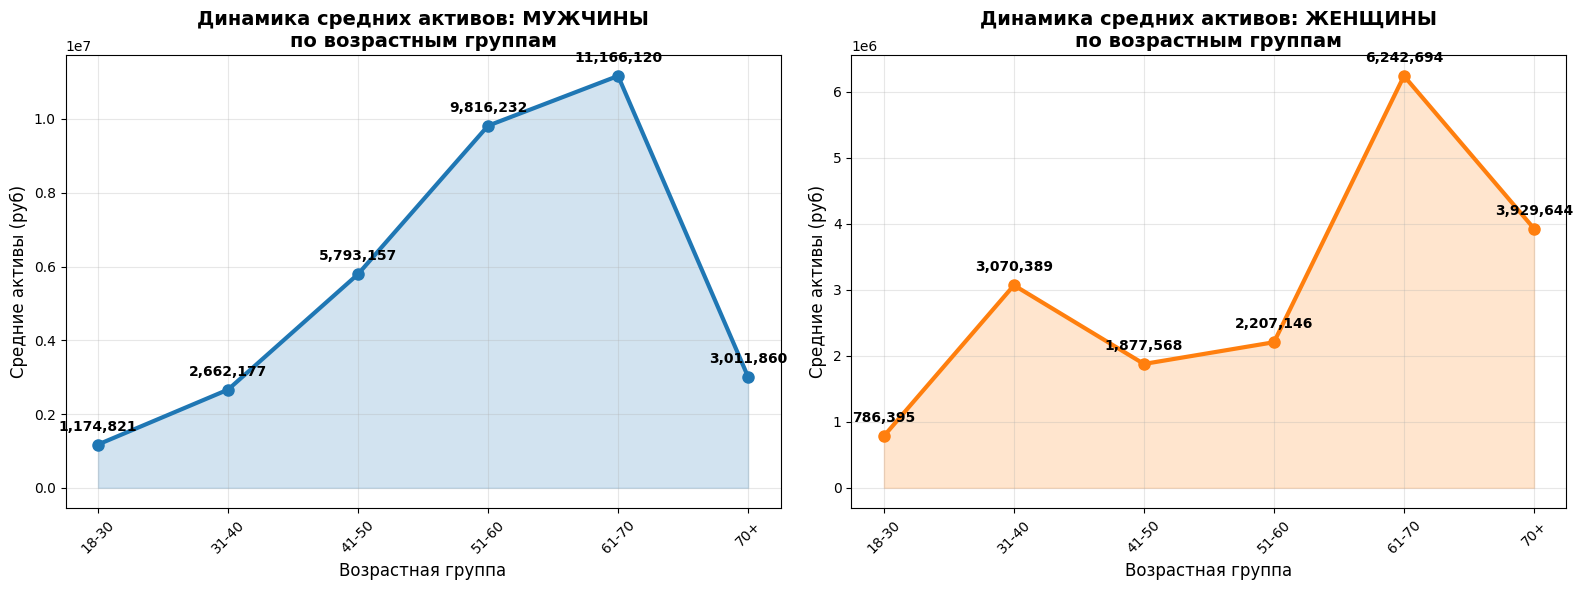

In [130]:
# Группируем данные по полу и возрастным группам
age_gender_stats = filtered_df.groupby(['gender', 'age_group'], observed=False)['assets'].agg(['mean', 'count']).round(2)

# Разделяем данные для мужчин и женщин
male_stats = age_gender_stats.loc['Мужской']
female_stats = age_gender_stats.loc['Женский']

# Создаем диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Диаграмма для мужчин
age_groups = male_stats.index.tolist()
male_means = male_stats['mean'].values

ax1.plot(age_groups, male_means, marker='o', linewidth=3, markersize=8, color='#1f77b4', label='Мужчины')
ax1.fill_between(age_groups, male_means, alpha=0.2, color='#1f77b4')
ax1.set_title('Динамика средних активов: МУЖЧИНЫ\nпо возрастным группам', fontweight='bold', fontsize=14)
ax1.set_xlabel('Возрастная группа', fontsize=12)
ax1.set_ylabel('Средние активы (руб)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Добавляем значения на точки
for i, (age_group, value) in enumerate(zip(age_groups, male_means)):
    ax1.annotate(f'{value:,.0f}', (age_group, value), textcoords="offset points", 
                xytext=(0,10), ha='center', fontweight='bold', fontsize=10)

# Диаграмма для женщин
female_means = female_stats['mean'].values

ax2.plot(age_groups, female_means, marker='o', linewidth=3, markersize=8, color='#ff7f0e', label='Женщины')
ax2.fill_between(age_groups, female_means, alpha=0.2, color='#ff7f0e')
ax2.set_title('Динамика средних активов: ЖЕНЩИНЫ\nпо возрастным группам', fontweight='bold', fontsize=14)
ax2.set_xlabel('Возрастная группа', fontsize=12)
ax2.set_ylabel('Средние активы (руб)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Добавляем значения на точки
for i, (age_group, value) in enumerate(zip(age_groups, female_means)):
    ax2.annotate(f'{value:,.0f}', (age_group, value), textcoords="offset points", 
                xytext=(0,10), ha='center', fontweight='bold', fontsize=10)

# Смотрим
plt.tight_layout()
plt.show()

#### Соотношение поплноений и снятий в зависимости от статуса клинета

- **Почему важно**: Ликвидность средств финансовой организации
- **Цель**: Выйти на положительные значения по всем метрикам
- **Действия**: Стимулирование вводов, ограничение массовых выводов

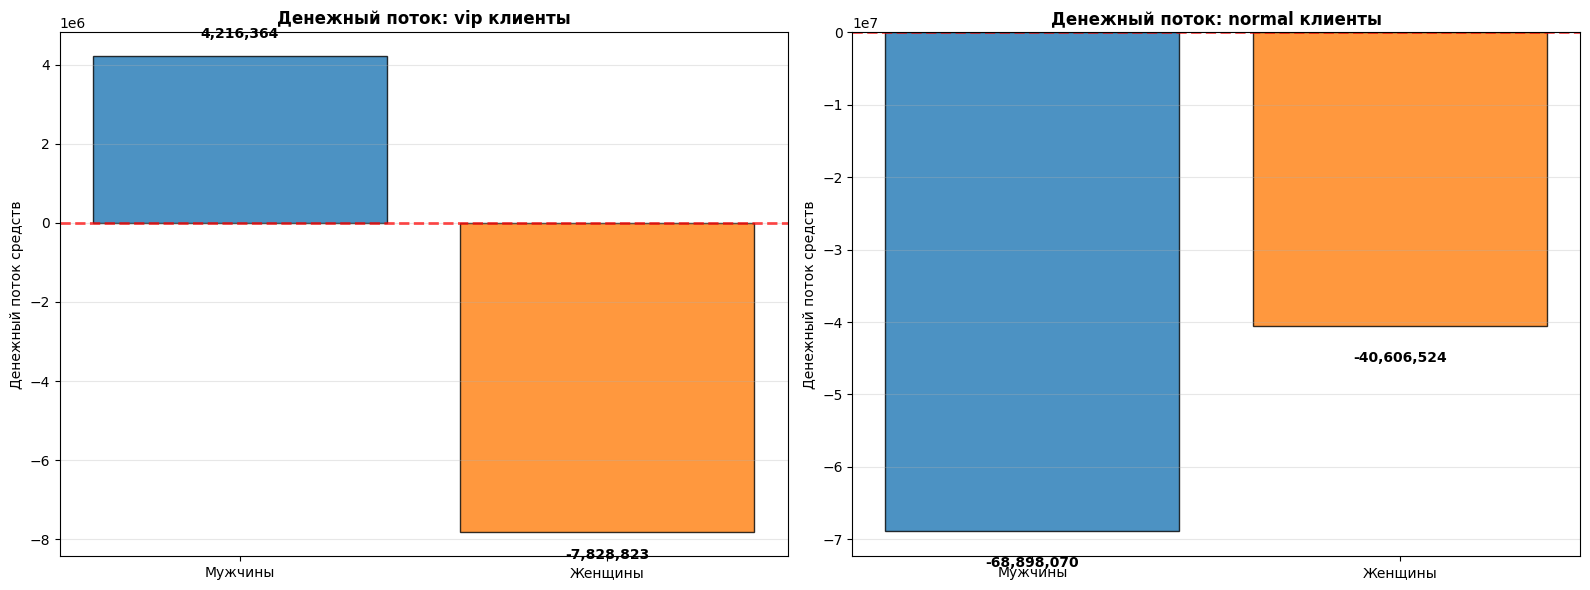

In [131]:
# Группируем данные по статусу и полу
status_gender_net_flow = money_df.groupby(['status', 'gender'], observed=False)['net_flow'].sum().unstack()

# Создаем две отдельные диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Диаграмма для vip клиентов
vip_data = [status_gender_net_flow.loc['vip', 'Мужской'], 
           status_gender_net_flow.loc['vip', 'Женский']]
vip_labels = ['Мужчины', 'Женщины']
vip_colors = ['#1f77b4', '#ff7f0e']

bars1 = ax1.bar(vip_labels, vip_data, color=vip_colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_title('Денежный поток: vip клиенты', fontweight='bold', fontsize=12)
ax1.set_ylabel('Денежный поток средств', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы для vip
for bar, value in zip(bars1, vip_data):
    va = 'bottom' if value >= 0 else 'top'
    y_offset = max(abs(val) for val in vip_data) * 0.05
    ax1.text(bar.get_x() + bar.get_width()/2, 
             value + (y_offset if value >= 0 else -y_offset),
             f'{value:,.0f}', 
             ha='center', va=va, fontweight='bold', fontsize=10)

# Линия нулевого баланса для vip
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)

# Диаграмма для normal клиентов
normal_data = [status_gender_net_flow.loc['normal', 'Мужской'], 
              status_gender_net_flow.loc['normal', 'Женский']]
normal_labels = ['Мужчины', 'Женщины']
normal_colors = ['#1f77b4', '#ff7f0e']

bars2 = ax2.bar(normal_labels, normal_data, color=normal_colors, alpha=0.8, edgecolor='black', linewidth=1)
ax2.set_title('Денежный поток: normal клиенты', fontweight='bold', fontsize=12)
ax2.set_ylabel('Денежный поток средств', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы для normal
for bar, value in zip(bars2, normal_data):
    va = 'bottom' if value >= 0 else 'top'
    y_offset = max(abs(val) for val in normal_data) * 0.05
    ax2.text(bar.get_x() + bar.get_width()/2, 
             value + (y_offset if value >= 0 else -y_offset),
             f'{value:,.0f}', 
             ha='center', va=va, fontweight='bold', fontsize=10)

# Линия нулевого баланса для normal
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)

# Смотрим
plt.tight_layout()
plt.show()

In [132]:
# Метрики денежного потока
print(f"\nVIP КЛИЕНТЫ:")
print(f"Мужчины: {vip_data[0]:,.0f} руб")
print(f"Женщины: {vip_data[1]:,.0f} руб")

print(f"\nNORMAL КЛИЕНТЫ:")
print(f"Мужчины: {normal_data[0]:,.0f} руб")
print(f"Женщины: {normal_data[1]:,.0f} руб")

total_vip = sum(vip_data)
total_normal = sum(normal_data)
print(f"\nОБЩИЕ ИТОГИ:")
print(f"Всего VIP: {total_vip:,.0f} руб")
print(f"Всего Normal: {total_normal:,.0f} руб")


VIP КЛИЕНТЫ:
Мужчины: 4,216,364 руб
Женщины: -7,828,823 руб

NORMAL КЛИЕНТЫ:
Мужчины: -68,898,070 руб
Женщины: -40,606,524 руб

ОБЩИЕ ИТОГИ:
Всего VIP: -3,612,459 руб
Всего Normal: -109,504,594 руб
